# Alunos



*   Denilson Alves Oliveira
*   Anderson Ferreira
*   Ítalo Timbó Santos
*   Artur Romão Soares Barbosa

# Introdução e Escopo do Projeto

O crescimento das redes sociais transformou plataformas como o YouTube em importantes espaços para a manifestação de opiniões sobre temas políticos, econômicos e sociais. A grande quantidade de comentários produzidos diariamente torna inviável sua análise manual, evidenciando a necessidade de técnicas de **Mineração de Textos** capazes de identificar padrões, tópicos recorrentes e percepções dos usuários de forma automatizada.

Neste projeto, foi desenvolvido um *pipeline* completo de Mineração de Textos utilizando comentários extraídos de um vídeo do YouTube relacionado a um debate político. O objetivo é identificar os principais temas discutidos pelos usuários, agrupar comentários semanticamente semelhantes e gerar *insights* acionáveis por meio da integração entre técnicas clássicas de *Machine Learning* e modelos de linguagem de grande porte (LLMs).

---

## 🛠️ O Pipeline de Mineração de Textos

O fluxo de trabalho proposto é composto pelas seguintes etapas sequenciais:

1. 📥 **Coleta automática** dos comentários utilizando a API do YouTube;
2. 📊 **Análise Exploratória dos Dados (EDA)**;
3. 🧼 **Pré-processamento textual** e limpeza de ruídos;
4. 🧠 **Geração de embeddings semânticos** utilizando o *Sentence-BERT*;
5. 📉 **Redução de dimensionalidade** com *UMAP*;
6. 🔀 **Clusterização dos comentários** utilizando o algoritmo denso *HDBSCAN* e *K-means*;
7. 📐 **Avaliação dos agrupamentos** por meio do índice de *Silhouette* e inspeção qualitativa;
8. 🏷️ **Rotulação automática dos clusters** utilizando o modelo *Gemini*, com saída estruturada e validada via *Pydantic*;
9. 💡 **Geração de insights estratégicos** para apoiar a tomada de decisão.

---

## 🔬 Abordagem Experimental

Durante os experimentos, foram avaliadas diferentes configurações do UMAP e do HDBSCAN. Após a análise rigorosa das métricas quantitativas e da coerência semântica dos agrupamentos, as configurações que produziram **7 e 9 clusters** foram selecionadas para uma análise detalhada. Ambas apresentaram o melhor equilíbrio entre qualidade estatística dos agrupamentos, interpretabilidade humana e representatividade dos temas encontrados.

> 🎯 **Expectativa do Projeto:** Ao final deste *pipeline*, espera-se demonstrar como a combinação entre *embeddings* contextuais, algoritmos de clusterização por densidade e LLMs pode transformar grandes volumes de comentários não estruturados em informações organizadas e úteis para apoiar análises e decisões.

#Instalação
 Instalamos pacotes usados.

 Se der erro no Colab, só executar uma segunda vez a célula.

In [ ]:
%pip install wordcloud
%pip install -q sentence-transformers
%pip install -q umap-learn
%pip install google-api-python-client


In [ ]:
%pip install -q nltk
%pip install -q hdbscan
%pip install -q -U google-genai
%pip install -q pydantic

#Importações

Aqui colocamos as bibliotecas que usamos no projeto

In [ ]:
import gdown
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
import numpy as np
import umap
from sklearn.manifold import trustworthiness
from googleapiclient.discovery import build
import nltk
from nltk.corpus import stopwords
import hdbscan
from sklearn.metrics import silhouette_score

In [ ]:
from google import genai
from google.genai import types
from typing import List, Literal
from sklearn.cluster import KMeans

In [ ]:
import google.generativeai as genai
import os
import json, re
from enum import Enum
from collections import Counter, defaultdict
from pydantic import BaseModel, ConfigDict, Field, field_validator

In [ ]:
from getpass import getpass

# Coleta do Corpus (Youtube)

Aqui pegamos 5000 dos comentários mais recentes do debate presidencial de 2022 do Brasil realizado em 28 de ago. de 2022.

Afim de trabalharmos sempre com o mesmo corpus o código abaixo salva esses comentários em um dataset("comentarios_youtube.csv")

Como cada vez que o código é executado ele gera um novo dataset com os comentários mais recentes, nos o executamos apenas uma vez e salvamos o resultado em um arquivo no drive manualmente.

Esse arquivo sempre será o mesmo e foi o importado para fazer todo o processo abaixo.

In [ ]:

# ================================
# Configurações
# ================================
API_KEY = getpass("Digite sua chave da API do Youtube: ")
VIDEO_ID = "WwdgWl_nmKI"
ARQUIVO_SAIDA = "comentarios_youtube.csv"

# ================================
# Função de coleta
# ================================

def minerar_muitos_comentarios(video_id, total_desejado=5000):

    youtube = build(
        "youtube",
        "v3",
        developerKey=API_KEY
    )

    comentarios = []
    next_page_token = None

    while len(comentarios) < total_desejado:

        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            pageToken=next_page_token,
            textFormat="plainText"
        )

        response = request.execute()

        for item in response["items"]:

            snippet = item["snippet"]["topLevelComment"]["snippet"]

            comentarios.append({

                "id": item["snippet"]["topLevelComment"]["id"],

                "autor": snippet["authorDisplayName"],

                "comentario": snippet["textDisplay"],

                "likes": snippet["likeCount"],

                "data": snippet["publishedAt"]

            })

            if len(comentarios) >= total_desejado:
                break

        print(f"Comentários coletados: {len(comentarios)}")

        next_page_token = response.get("nextPageToken")

        if not next_page_token:
            print("Não há mais comentários disponíveis.")
            break

    return pd.DataFrame(comentarios)

# ================================
# Salvar Dataset
# ================================

def salvar_dataset(df, caminho):

    df.to_csv(
        caminho,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\nDataset salvo com sucesso em '{caminho}'")

# ================================
# Execução
# ================================

df = minerar_muitos_comentarios(
    VIDEO_ID,
    total_desejado=5000
)

salvar_dataset(df, ARQUIVO_SAIDA)

print("\nPrimeiras linhas do dataset:")

display(df.head())

Comentários coletados: 100
Comentários coletados: 200
Comentários coletados: 300
Comentários coletados: 400
Comentários coletados: 500
Comentários coletados: 600
Comentários coletados: 700
Comentários coletados: 800
Comentários coletados: 900
Comentários coletados: 1000
Comentários coletados: 1100
Comentários coletados: 1200
Comentários coletados: 1300
Comentários coletados: 1400
Comentários coletados: 1500
Comentários coletados: 1600
Comentários coletados: 1700
Comentários coletados: 1800
Comentários coletados: 1900
Comentários coletados: 2000
Comentários coletados: 2100
Comentários coletados: 2200
Comentários coletados: 2300
Comentários coletados: 2400
Comentários coletados: 2500
Comentários coletados: 2600
Comentários coletados: 2700
Comentários coletados: 2800
Comentários coletados: 2900
Comentários coletados: 3000
Comentários coletados: 3100
Comentários coletados: 3200
Comentários coletados: 3300
Comentários coletados: 3400
Comentários coletados: 3500
Comentários coletados: 3600
C

,id,autor,comentario,likes,data
0,UgyOaCGJxSo8fyN4-Hd4AaABAg,@Shokudaikiri_Mitsutada,"Em pleno 2026, eu só vim aqui por causa dessa ...",1,2026-06-10T06:50:24Z
1,Ugz5SPEYHc8Sbp5u8gB4AaABAg,@tfimp,"imaginem oque vai ser o debate em 2026, Lula e...",1,2026-05-24T15:57:17Z
2,Ugz0ro7uMduZfBa6RNN4AaABAg,@DiegoCardoso-p9t,Quem tá ansioso pelo debate de 2026 ???,4,2026-04-26T16:40:13Z
3,Ugx7vBSbOSYKrzk4F_J4AaABAg,@Testedealgoritimo,"auto promocao, ataques pessoais e fake news(um...",0,2026-02-17T21:32:26Z
4,UgyEjPkeFmP5KZbEBBR4AaABAg,@Testedealgoritimo,a Soraya tendo que baixar o nivel (triste. nos...,0,2026-02-17T21:28:55Z


#Carregar o Dataset

Aqui eu carrego o dataset do Google Drive, pois, relembrando, ao executar o código de coleta de corpus ele sempre gera um dataset diferente, logo eu o executei apenas uma vez e salvei o resultado no Drive.

Se vc quiser trabalhar com outros comentários basta executar o código de importação novamente, salvar o dataset no drive e substituir o file_id com o id da pasta no drive(*lembre-se de compartilhar como leitor para qualquer um que tiver o link*)

In [ ]:

file_id = '15NlImrAKMWDwhwOOs7ySikWXzvrlxE0l'
url = f'https://drive.google.com/uc?id={file_id}'

# O gdown lida com o redirecionamento e arquivos grandes do Drive
gdown.download(url, 'comentarios.csv', quiet=False)

# Agora o pandas conseguirá ler
try:
    # Testando com o separador comum de arquivos brasileiros (;) e encoding latin1
    df = pd.read_csv('comentarios.csv')
    print("Arquivo carregado com sucesso!")
    display(df.head())
except Exception as e:
    print("Tentando com configurações padrão...")
    df = pd.read_csv('comentarios.csv', compression='gzip')
    display(df.head())

Downloading...
From: https://drive.google.com/uc?id=15NlImrAKMWDwhwOOs7ySikWXzvrlxE0l
To: /content/comentarios.csv
100%|██████████| 958k/958k [00:00<00:00, 78.5MB/s]

Arquivo carregado com sucesso!


,id,autor,comentario,likes,data
0,UgyOaCGJxSo8fyN4-Hd4AaABAg,@Shokudaikiri_Mitsutada,"Em pleno 2026, eu só vim aqui por causa dessa ...",1,2026-06-10T06:50:24Z
1,Ugz5SPEYHc8Sbp5u8gB4AaABAg,@tfimp,"imaginem oque vai ser o debate em 2026, Lula e...",1,2026-05-24T15:57:17Z
2,Ugz0ro7uMduZfBa6RNN4AaABAg,@DiegoCardoso-p9t,Quem tá ansioso pelo debate de 2026 ???,4,2026-04-26T16:40:13Z
3,Ugx7vBSbOSYKrzk4F_J4AaABAg,@Testedealgoritimo,"auto promocao, ataques pessoais e fake news(um...",0,2026-02-17T21:32:26Z
4,UgyEjPkeFmP5KZbEBBR4AaABAg,@Testedealgoritimo,a Soraya tendo que baixar o nivel (triste. nos...,0,2026-02-17T21:28:55Z


# Análise Exploratória (EDA)  

Aqui vou ver comos os dados estão organizados para sabermos que tipo de pré-processamento será o mais adequado.

## 1- Informações gerais

* quantidade de linhas
* tipos das colunas
* valores *nulos*

In [ ]:
print(f"Número de comentários: {len(df)}")

df.info()

Número de comentários: 5000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5000 non-null   object
 1   autor       5000 non-null   object
 2   comentario  5000 non-null   object
 3   likes       5000 non-null   int64 
 4   data        5000 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


## 2- Primeiras linhas

In [ ]:
df.head()

,id,autor,comentario,likes,data
0,UgyOaCGJxSo8fyN4-Hd4AaABAg,@Shokudaikiri_Mitsutada,"Em pleno 2026, eu só vim aqui por causa dessa ...",1,2026-06-10T06:50:24Z
1,Ugz5SPEYHc8Sbp5u8gB4AaABAg,@tfimp,"imaginem oque vai ser o debate em 2026, Lula e...",1,2026-05-24T15:57:17Z
2,Ugz0ro7uMduZfBa6RNN4AaABAg,@DiegoCardoso-p9t,Quem tá ansioso pelo debate de 2026 ???,4,2026-04-26T16:40:13Z
3,Ugx7vBSbOSYKrzk4F_J4AaABAg,@Testedealgoritimo,"auto promocao, ataques pessoais e fake news(um...",0,2026-02-17T21:32:26Z
4,UgyEjPkeFmP5KZbEBBR4AaABAg,@Testedealgoritimo,a Soraya tendo que baixar o nivel (triste. nos...,0,2026-02-17T21:28:55Z


## 3- Valores Ausentes

In [ ]:
df.isnull().sum()

,0
id,0
autor,0
comentario,0
likes,0
data,0


In [ ]:
df = df.dropna(subset=["comentario"])
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5000 non-null   object
 1   autor       5000 non-null   object
 2   comentario  5000 non-null   object
 3   likes       5000 non-null   int64 
 4   data        5000 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


## 4- Comentários duplicados

In [ ]:
duplicados = df.duplicated(subset="comentario").sum()

print(f"Comentários duplicados: {duplicados}")

Comentários duplicados: 279


In [ ]:
df[df.duplicated(subset="comentario", keep=False)].sort_values("comentario")

,id,autor,comentario,likes,data
4142,Ugze9m1NqSfOUHMJY5l4AaABAg,@sisitaillc4688,##%$$....FALTOU O CANDIDATO ESCOLHIDO POR IAHW...,0,2022-08-30T19:23:17Z
4143,UgwU2BW7Retdhms5Zqd4AaABAg,@sisitaillc4688,##%$$....FALTOU O CANDIDATO ESCOLHIDO POR IAHW...,0,2022-08-30T19:23:00Z
164,Ugy958JIU9d8iEDDcM14AaABAg,@damianacristina7257,#22,0,2022-10-28T23:23:16Z
1078,UgxqrmvQRdD1poXvjCh4AaABAg,@mariaalvarenga4744,#22,0,2022-09-30T13:19:38Z
3165,Ugyu00nSSc2Hz07oWMp4AaABAg,@carlosgevergier3322,10,0,2022-08-31T05:49:19Z
...,...,...,...,...,...
3061,UgzIEwi6FFnP2NsfjiJ4AaABAg,@crisssrosa,🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷,0,2022-08-31T12:27:41Z
344,UgwMY5TwRHS6rjlcQjl4AaABAg,@abimaelcavalcante2921,🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷,0,2022-10-17T01:09:05Z
2186,UgzeZAgAbrOrtaPqRo14AaABAg,@caioazevedo.0,🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷,0,2022-09-02T21:18:12Z
1361,UgzQwxFL7sb0p6Hhqo94AaABAg,@cliciacarvalhais,🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷,0,2022-09-24T22:25:38Z


Foram identificados 279 comentários com texto duplicado. Esses registros foram mantidos, pois representam manifestações independentes de usuários diferentes e ajudam a refletir a frequência real das opiniões no corpus.

## 5- Distribuição do número de likes

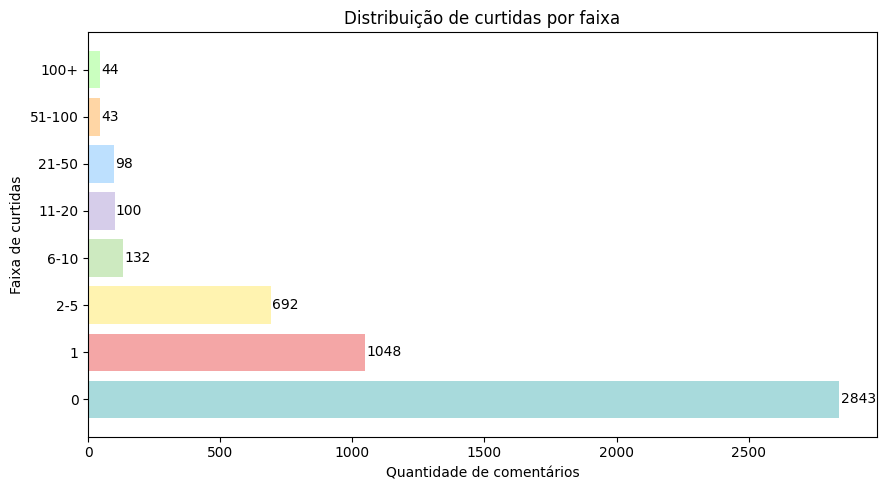

In [ ]:
faixas = pd.cut(
    df["likes"],
    bins=[-1,0,1,5,10,20,50,100,1000],
    labels=[
        "0",
        "1",
        "2-5",
        "6-10",
        "11-20",
        "21-50",
        "51-100",
        "100+"
    ]
)

contagem = faixas.value_counts().sort_index()

cores = [
    "#A8DADC",
    "#F4A6A6",
    "#FFF3B0",
    "#CDEAC0",
    "#D6CDEA",
    "#BDE0FE",
    "#FFD6A5",
    "#CAFFBF"
]

plt.figure(figsize=(9,5))

bars = plt.barh(
    contagem.index.astype(str),
    contagem.values,
    color=cores
)

for bar in bars:
    largura = bar.get_width()
    plt.text(
        largura + 5,
        bar.get_y() + bar.get_height()/2,
        str(int(largura)),
        va="center"
    )

plt.xlabel("Quantidade de comentários")
plt.ylabel("Faixa de curtidas")
plt.title("Distribuição de curtidas por faixa")

plt.tight_layout()

plt.show()

## 6- Tamanho dos comentários

In [ ]:
df["num_caracteres"] = df["comentario"].str.len()

df["num_palavras"] = df["comentario"].str.split().str.len()

df[["num_caracteres","num_palavras"]].describe()

,num_caracteres,num_palavras
count,5000.000000,5000.000000
mean,115.659400,20.020800
std,204.013564,34.790942
min,1.000000,1.000000
25%,29.000000,5.000000
50%,62.000000,11.000000
75%,129.000000,23.000000
max,4829.000000,819.000000


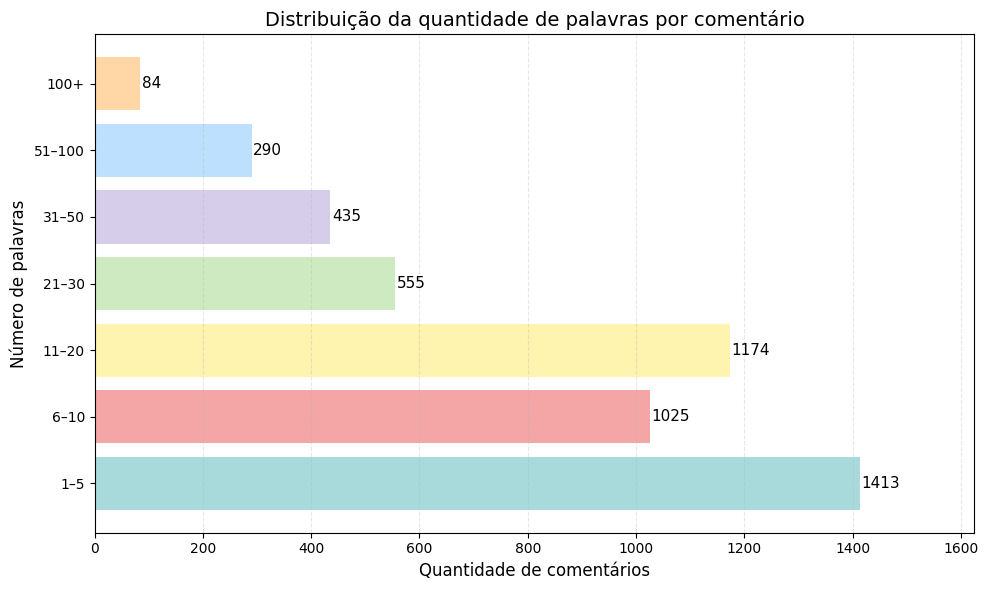

In [ ]:

# Criando faixas de quantidade de palavras
faixas = pd.cut(
    df["num_palavras"],
    bins=[0, 5, 10, 20, 30, 50, 100, 200],
    labels=[
        "1–5",
        "6–10",
        "11–20",
        "21–30",
        "31–50",
        "51–100",
        "100+"
    ]
)

contagem = faixas.value_counts().sort_index()

cores = [
    "#A8DADC",
    "#F4A6A6",
    "#FFF3B0",
    "#CDEAC0",
    "#D6CDEA",
    "#BDE0FE",
    "#FFD6A5"
]

plt.figure(figsize=(10,6))

bars = plt.barh(
    contagem.index.astype(str),
    contagem.values,
    color=cores
)

# Adiciona os valores ao lado das barras
for bar in bars:
    largura = bar.get_width()
    plt.text(
        largura + 3,
        bar.get_y() + bar.get_height()/2,
        str(int(largura)),
        va="center",
        fontsize=11
    )

plt.title("Distribuição da quantidade de palavras por comentário", fontsize=14)
plt.xlabel("Quantidade de comentários", fontsize=12)
plt.ylabel("Número de palavras", fontsize=12)

plt.xlim(0, contagem.max() * 1.15)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 7- Comentários mais curtos

In [ ]:
df.sort_values("num_palavras").head(20)

,id,autor,comentario,likes,data,num_caracteres,num_palavras
4996,UgzTXPRrRxs35zPBiL14AaABAg,@MARLYDASILVAsIVA,Que.ver.au.vivo.todo.procamar,0,2022-08-30T12:40:21Z,29,1
10,UgzgumUscsis6AMoRuB4AaABAg,@hiagocristhian,2:12:29,0,2025-11-06T13:37:43Z,7,1
35,UgwtOfA3MvuNX8dYVsB4AaABAg,@jackelinesilva7808,Infsttritura,1,2024-03-21T02:32:40Z,12,1
37,UgzZ9i5cRtngPpu_xX14AaABAg,@bucetaboa-y4b,别再删评论了,1,2024-03-17T19:03:56Z,6,1
1187,UgyqScJ74nRlbC-cMJN4AaABAg,@DiogoAmorym,22🇧🇷,1,2022-09-29T00:39:28Z,4,1
1159,UgwjHTejc-9b-uR1Z4N4AaABAg,@emanoelnazario588,Verdade,1,2022-09-29T22:10:38Z,7,1
42,UgxSuifNLXqxfELApOR4AaABAg,@bucetaboa-y4b,Bolsominio,1,2024-03-17T15:43:50Z,10,1
61,UgzqQmv6AjXN5Me0q_p4AaABAg,@marcoantoniomarcoantonio7666,vk,0,2023-07-24T00:07:01Z,2,1
63,UgylayNbgylWCO4T_gN4AaABAg,@josewilson____,2:59:40,4,2023-06-30T22:48:10Z,7,1
4859,UgyyE0bL1VXHWFjbKgZ4AaABAg,@FelipeAraujo-ho6sp,22,0,2022-08-30T13:49:58Z,2,1


## 8- Comentários mais longos

In [ ]:
df.sort_values("num_palavras", ascending=False).head(10)

,id,autor,comentario,likes,data,num_caracteres,num_palavras
3151,Ugy_sgkXZ3ECUBY9l-Z4AaABAg,@umobservador.2330,Sou filho de um Militar um Ex-Combatente da Ma...,0,2022-08-31T06:52:49Z,4829,819
1616,UgyCBrto1Be8HhZqZaB4AaABAg,@ClaudeirNJ,SUGESTOES DE REFORMAS PARA O GOVERSNO ATUAL\n\...,0,2022-09-15T19:11:14Z,4556,712
956,UgxZBLz1m00mqcFS91F4AaABAg,@capivaraancap1433,2:54:30 - Ser contra a liberalização das droga...,0,2022-10-02T13:27:53Z,4297,699
4415,UgzE6tUlfvcqaGPOH6t4AaABAg,@07ZeroSete,Ciro é um dos maiores marqueteiros desse debat...,0,2022-08-30T17:00:00Z,2916,520
4763,Ugy_szyrGXw5ZnsQBcR4AaABAg,@si.si97,"Aumentar salário mínimo, sendo que em governo ...",0,2022-08-30T14:38:05Z,2614,463
305,UgwFH8ubcKRydxIJgYJ4AaABAg,@nalldoreisreis2032,Olha o que eu me lembro bem que os ministros ...,1,2022-10-17T02:11:34Z,2545,425
962,Ugxntf_ZXLCuAWKHJ0x4AaABAg,@capivaraancap1433,2:16:48 - Opa! Salto Lógico não sei se foi sem...,0,2022-10-02T12:01:02Z,2264,395
959,UgywfhSuTm020UfpXnh4AaABAg,@capivaraancap1433,2:21:53 - Uma pessoa que usa esse slogan defin...,0,2022-10-02T12:19:24Z,2272,365
1001,UgxoZec6fDX18SaPGON4AaABAg,@capivaraancap1433,29:47 - PT MRDA! Essa expressão pelo visto é ...,0,2022-10-01T13:13:02Z,2059,338
4952,Ugx_D8Ge_VsYsgK0V7Z4AaABAg,@oprofetadosom2184,Boas entrevistas gostamos principalmente do Bo...,1,2022-08-30T13:00:48Z,1806,329


## 9- Estatísticas da quantidade de palavras

In [ ]:
print("Média:", df["num_palavras"].mean())

print("Mediana:", df["num_palavras"].median())

print("Máximo:", df["num_palavras"].max())

print("Mínimo:", df["num_palavras"].min())

Média: 20.0208
Mediana: 11.0
Máximo: 819
Mínimo: 1


## 10- Nuvem de palavras

Faço uma cópia do dataset original e retiro as stopwords para melhor vizualização da nuvem de palavras.

In [ ]:
nltk.download("stopwords")
# Cria uma cópia do dataset
df_wordcloud = df.copy()

# Stopwords em português
stop_words = set(stopwords.words("portuguese"))

# Função para remover stopwords
def remover_stopwords(texto):
    palavras = str(texto).split()
    palavras = [p for p in palavras if p.lower() not in stop_words]
    return " ".join(palavras)

# Cria uma nova coluna
df_wordcloud["comentario_sem_stopwords"] = (
    df_wordcloud["comentario"]
    .fillna("")
    .apply(remover_stopwords)
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


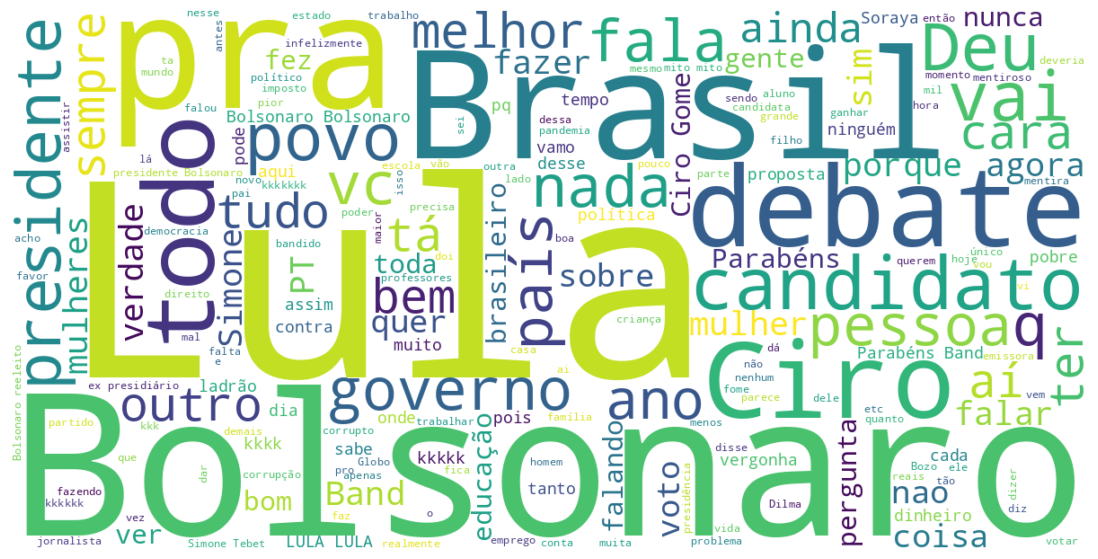

In [ ]:
texto = " ".join(df_wordcloud["comentario_sem_stopwords"])

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(texto)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

## 11- Palavras mais frequentes

In [ ]:
texto = " ".join(df_wordcloud["comentario_sem_stopwords"])

palavras = texto.split()

freq = Counter(palavras)

freq.most_common(20)

[('Bolsonaro', 817),
 ('Lula', 665),
 ('pra', 524),
 ('Ciro', 340),
 ('Brasil', 326),
 ('vai', 304),
 ('debate', 278),
 ('presidente', 270),
 ('22', 246),
 (',', 227),
 ('todos', 226),
 ('povo', 215),
 ('lula', 197),
 ('q', 197),
 ('melhor', 177),
 ('2022', 176),
 ('fala', 175),
 ('ter', 174),
 ('Simone', 169),
 ('cara', 159)]

## 12- Comentários por data

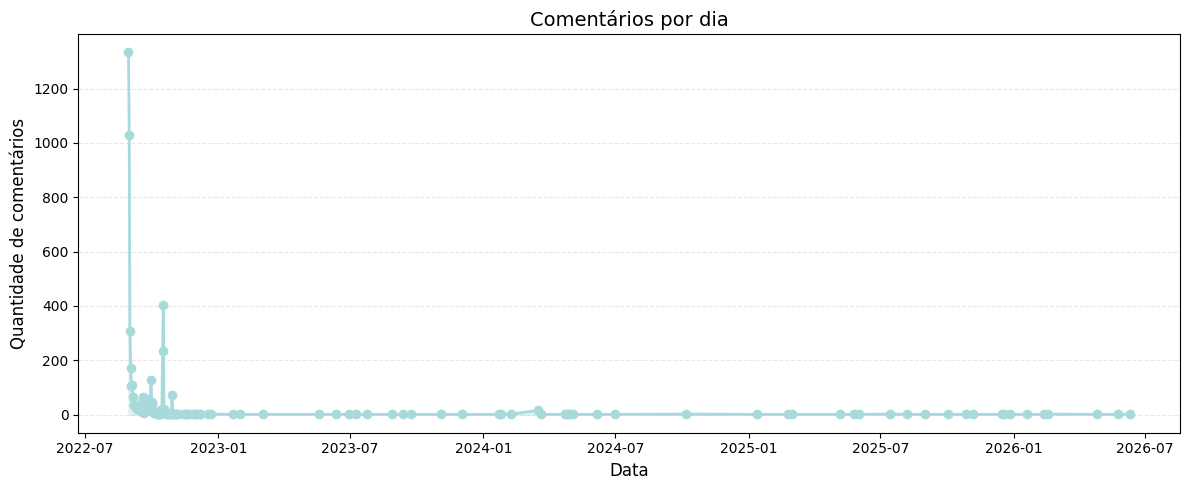

In [ ]:
import matplotlib.pyplot as plt

# Converter a data
df["data"] = pd.to_datetime(df["data"])
df["dia"] = df["data"].dt.date

# Contagem de comentários por dia
comentarios_por_dia = df.groupby("dia").size()

plt.figure(figsize=(12,5))

plt.plot(
    comentarios_por_dia.index,
    comentarios_por_dia.values,
    marker="o",
    linewidth=2,
    color="#A8DADC"   # Azul pastel
)

plt.fill_between(
    comentarios_por_dia.index,
    comentarios_por_dia.values,
    color="#A8DADC",
    alpha=0.3
)

plt.title("Comentários por dia", fontsize=14)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Quantidade de comentários", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

A maioria dos comentário foram feitos durante ou próximo da gravação do debate.

## 13- Conclusão da Análise Exploratória do Corpus

A análise exploratória permitiu compreender as principais características do corpus antes da etapa de pré-processamento e geração dos embeddings. Após a coleta dos comentários do vídeo do debate presidencial de 2022.

---

### 📌 Inspeção de Dados e Comentários Duplicados

Durante a inspeção dos dados também foram encontrados 279 comentários com conteúdo textual idêntico. Optou-se por não removê-los, uma vez que esses comentários pertencem a usuários diferentes e representam manifestações independentes sobre o mesmo tema.

> Em um contexto de mineração de opiniões, comentários repetidos podem indicar consenso, reforço de determinadas ideias ou elevada recorrência de determinados assuntos, constituindo uma informação relevante para a análise e para a formação dos clusters.

---

### 📅 Análise Temporal

A análise temporal mostrou que a maior parte dos comentários foi publicada nos dias próximos à gravação e divulgação do debate. Isso indica que o corpus representa principalmente as reações iniciais do público ao episódio, refletindo as discussões e opiniões mais imediatas ou próximas a data de divulgação.

---

### 📊 Distribuição e Volumetria das Palavras

A distribuição da quantidade de palavras revelou que o corpus é composto predominantemente por comentários curtos. A média foi de 20,02 palavras por comentário, enquanto a mediana foi de 11 palavras, indicando uma distribuição assimétrica à direita, influenciada por um número reduzido de comentários muito extensos. Observou-se ainda que:

* **25%** dos comentários possuem até **5 palavras**;
* **50%** possuem até **11 palavras**;
* **75%** possuem até **23 palavras**.

Esses resultados evidenciam que a maior parte das interações é composta por mensagens objetivas. Por outro lado, também existem comentários significativamente maiores, capazes de fornecer argumentos mais completos e detalhados.

Em relação ao tamanho dos textos, o menor comentário encontrado possui apenas 1 caractere (ou emoji), enquanto o maior contém 819 palavras, totalizando 4829 caracteres. Essa variação demonstra uma elevada heterogeneidade no corpus, reunindo desde respostas extremamente curtas até comentários bastante elaborados.

---

### 📈 Engajamento (Distribuição de Curtidas)

A análise da distribuição de curtidas mostrou que a maioria dos comentários recebeu nenhuma ou poucas curtidas. Especificamente, **2843 comentários não receberam nenhuma curtida**, enquanto **1048 receberam apenas uma curtida**. Apenas uma pequena parcela dos comentários ultrapassou cinquenta curtidas, indicando uma distribuição fortemente concentrada em valores baixos.

---

### 🧠 Análise Lexical e Estratégia de Pré-Processamento

A nuvem de palavras e a análise das palavras mais frequentes evidenciaram a predominância de nome dos candidatos. Esse resultado era esperado, uma vez que essas palavras são naturalmente muito frequentes debates presidenciais onde o usuário cita o candidato ao qual apoia ou não apoia.

**Decisão de Projeto:** Apesar disso, optou-se por não remover as stopwords durante o pré-processamento.

Essa decisão foi tomada porque o projeto utilizará embeddings contextuais, capazes de considerar o contexto completo das frases. Diferentemente de abordagens tradicionais como Bag of Words ou TF-IDF, os modelos baseados em Transformers utilizam essas palavras para compreender relações sintáticas e semânticas entre os termos. Assim, a remoção indiscriminada de stopwords poderia reduzir a qualidade da representação vetorial dos comentários e comprometer a formação dos clusters.

---

### 🎯 Conclusão

De forma geral, a análise exploratória mostrou que o corpus apresenta boa qualidade para as etapas seguintes do projeto. Os comentários abrangem diferentes tamanhos, apresentam elevada concentração temporal em torno do evento analisado e preservam repetições que representam opiniões independentes dos usuários.


# Pré-Processamento

## Abordagem

Como vamos usar embeddings contextuais (Sentence Transformers/BERT) e depois HDBSCAN, o pré-processamento deve ser bem mais leve do que o usado em abordagens clássicas (Bag of Words ou TF-IDF).  

Então não vamos remover stopwords, fazer stemming ou lematização ou remover acentos.

Cometários vazios já foram removidos.

Nós vamos:

1. Remover espaços extras
2. Remover quebras de linhas
3. Remover URls
4. Remover menções(@)
5. Remover Hashtags
6. Remover comentários muito pequenos(até 3 palavras)
7. Colocar tudo em minúsculo
8. Remover excesso de pontuação

In [ ]:
def preprocessar_comentario(texto):
    """
    Realiza o pré-processamento de um comentário.
    Retorna None caso o comentário deva ser descartado ou esteja vazio.
    """
    # Verifica valores nulos iniciais
    if pd.isna(texto):
        return None

    # Garante que é string
    texto = str(texto)

    # 1. Remover espaços extras iniciais e quebras de linha
    texto = texto.replace("\n", " ").replace("\r", " ")
    texto = texto.strip()

    # 2. Remover URLs
    texto = re.sub(r"http\S+|www\S+", "", texto)

    # 3. Remover menções (@usuario)
    texto = re.sub(r"@\w+", "", texto)

    # 4. Remover hashtags (mantendo apenas a palavra)
    texto = re.sub(r"#(\w+)", r"\1", texto)

    # 5. Colocar tudo em minúsculo
    texto = texto.lower()

    # 6. Remover excesso de pontuação ("!!!!!" -> "!")
    texto = re.sub(r'([!?.,])\1+', r'\1', texto)

    # 7. Limpeza final de espaços em branco duplos
    texto = re.sub(r"\s+", " ", texto).strip()

    # === CHECAGEM DE LINHAS VAZIAS E TAMANHO MÍNIMO ===

    # Se após as remoções o texto ficou vazio ou só com espaços: descarta
    if not texto or texto.isspace():
        return None

    # 8. Remover comentários muito pequenos (menos de 3 palavras)
    if len(texto.split()) < 3:
        return None

    return texto

In [ ]:
def preprocessar_dataframe(df):
    df = df.copy()

    tamanho_original = len(df)

    df["comentario_limpo"] = df["comentario"].apply(preprocessar_comentario)

    df = df.dropna(subset=["comentario_limpo"]).reset_index(drop=True)
    df = df.drop(index=0).reset_index(drop=True) # Remove o primeiro comentário pois é um link
    print(f"Comentários originais: {tamanho_original}")
    print(f"Comentários após o pré-processamento: {len(df)}")
    print(f"Comentários removidos: {tamanho_original - len(df)}")

    return df

In [ ]:
df_limpo = preprocessar_dataframe(df)

Comentários originais: 5000
Comentários após o pré-processamento: 4377
Comentários removidos: 623


In [ ]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4377 entries, 0 to 4376
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                4377 non-null   object             
 1   autor             4377 non-null   object             
 2   comentario        4377 non-null   object             
 3   likes             4377 non-null   int64              
 4   data              4377 non-null   datetime64[ns, UTC]
 5   num_caracteres    4377 non-null   int64              
 6   num_palavras      4377 non-null   int64              
 7   dia               4377 non-null   object             
 8   comentario_limpo  4377 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(3), object(5)
memory usage: 307.9+ KB


In [ ]:
df_limpo.head()

,id,autor,comentario,likes,data,num_caracteres,num_palavras,dia,comentario_limpo
0,Ugz5SPEYHc8Sbp5u8gB4AaABAg,@tfimp,"imaginem oque vai ser o debate em 2026, Lula e...",1,2026-05-24 15:57:17+00:00,439,77,2026-05-24,"imaginem oque vai ser o debate em 2026, lula e..."
1,Ugz0ro7uMduZfBa6RNN4AaABAg,@DiegoCardoso-p9t,Quem tá ansioso pelo debate de 2026 ???,4,2026-04-26 16:40:13+00:00,39,8,2026-04-26,quem tá ansioso pelo debate de 2026 ?
2,Ugx7vBSbOSYKrzk4F_J4AaABAg,@Testedealgoritimo,"auto promocao, ataques pessoais e fake news(um...",0,2026-02-17 21:32:26+00:00,64,10,2026-02-17,"auto promocao, ataques pessoais e fake news(um..."
3,UgyEjPkeFmP5KZbEBBR4AaABAg,@Testedealgoritimo,a Soraya tendo que baixar o nivel (triste. nos...,0,2026-02-17 21:28:55+00:00,83,13,2026-02-17,a soraya tendo que baixar o nivel (triste. nos...
4,UgwTy0llKBm64ln-zDp4AaABAg,@alew7,2:06:59 a parte mais engraçada que certamente ...,2,2026-02-11 01:21:24+00:00,70,12,2026-02-11,2:06:59 a parte mais engraçada que certamente ...


Aqui eu salvo o df_limpo e o salvo manualmente no drive.

In [ ]:
df_limpo.to_csv(
    "comentarios_preprocessados.csv",
    index=False,
    encoding="utf-8-sig"
)

#Embeddings

Para representar semanticamente os comentários do YouTube, optou-se pela utilização do modelo intfloat/multilingual-e5-base, pertencente à família Sentence Transformers. A escolha foi baseada nas características do corpus e nos objetivos do projeto, que envolvem a geração de embeddings para posterior redução de dimensionalidade (UMAP), clusterização (HDBSCAN) e interpretação dos clusters por um LLM.

Diferentemente do BERT tradicional, que foi desenvolvido principalmente para tarefas de compreensão de linguagem (como classificação e preenchimento de palavras mascaradas), o modelo E5 foi treinado especificamente para produzir representações vetoriais de alta qualidade para sentenças e pequenos textos. Isso faz com que comentários semanticamente semelhantes sejam representados por vetores próximos no espaço vetorial, característica essencial para algoritmos de agrupamento baseados em densidade, como o HDBSCAN.

Além disso, o modelo possui suporte multilíngue, incluindo o português, permitindo trabalhar diretamente com os comentários originais sem necessidade de tradução. Essa decisão preserva nuances linguísticas importantes, como gírias, expressões idiomáticas, negações e construções típicas da língua portuguesa.

Outro fator relevante é que o corpus analisado é composto por comentários de redes sociais, caracterizados por linguagem informal, uso frequente de emojis, pontuação expressiva e frases curtas. O modelo E5 consegue representar adequadamente esse tipo de texto, preservando relações semânticas importantes entre os comentários e favorecendo a formação de clusters mais coerentes.

Embora existam modelos menores, como o paraphrase-multilingual-MiniLM-L12-v2, optou-se pelo intfloat/multilingual-e5-base devido à sua maior capacidade de representação semântica. Como o corpus possui aproximadamente 4377 comentários, o aumento no custo computacional é pequeno e plenamente suportado pelo Google Colab, tornando vantajosa a utilização de um modelo com maior qualidade dos embeddings.

## 1- Carregar o modelo

In [ ]:
modelo = SentenceTransformer("intfloat/multilingual-e5-base")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

## 2- Preparar os textos

In [ ]:
textos = df_limpo["comentario_limpo"].tolist()

## 3- Gerar os embeddings

In [ ]:
embeddings = modelo.encode(
    textos,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

In [ ]:
print(embeddings.shape)

(4377, 768)


##4- Salvar  

Faço o mesmo esquema baixar e fazer o upload para o drive manualmente e depois baixar do drive.

In [ ]:
np.save("embeddings.npy", embeddings)

## 5- Carregar do Drive

In [ ]:

file_id = "1Jwd7bMLORhiYGGLfvd0AKFubpzwBHeM4"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(
    url,
    "embeddings.npy",
    quiet=False
)

embeddings = np.load("embeddings.npy")
print("\n")
print("Shape:",embeddings.shape)

Downloading...
From: https://drive.google.com/uc?id=1Jwd7bMLORhiYGGLfvd0AKFubpzwBHeM4
To: /content/embeddings.npy
100%|██████████| 13.4M/13.4M [00:00<00:00, 60.1MB/s]



Shape: (4377, 768)


#Redução de Dimensionalidade (UMAP)

## Por que usar UMAP antes do HDBSCAN?

Os embeddings possuem:
* **1280 comentários × 768 dimensões**

---

## ⚠️ O Desafio das Altas Dimensões

O HDBSCAN consegue trabalhar diretamente com 768 dimensões, porém isso apresenta alguns problemas:

* **Maldição da dimensionalidade:** Distâncias em altas dimensões tornam-se menos informativas.
* **Desempenho:** O algoritmo fica mais lento.
* **Qualidade:** Os clusters tendem a ficar menos definidos.

---

## 🎯 A Solução com UMAP

O UMAP reduz essas 768 dimensões para um espaço muito menor (geralmente entre 5 e 50 dimensões), preservando a estrutura semântica dos dados.

 Foram avaliadas três configurações (n_components = 5, n_components = 10 e n_components = 15) com o objetivo de identificar aquela que produzisse agrupamentos mais coerentes quando utilizada em conjunto com o algoritmo HDBSCAN. A comparação entre as configurações foi realizada por meio de métricas de qualidade de clusterização e análise qualitativa dos grupos obtidos.

## UMAP 5 dimensões

In [ ]:
umap_5 = umap.UMAP(
    n_neighbors=13,
    n_components=5,
    metric="cosine",
    min_dist=0.0,
    random_state=42
)

embeddings_umap_5 = umap_5.fit_transform(embeddings)

print("Formato:", embeddings_umap_5.shape)

np.save("embeddings_umap_5.npy", embeddings_umap_5)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Formato: (4377, 5)


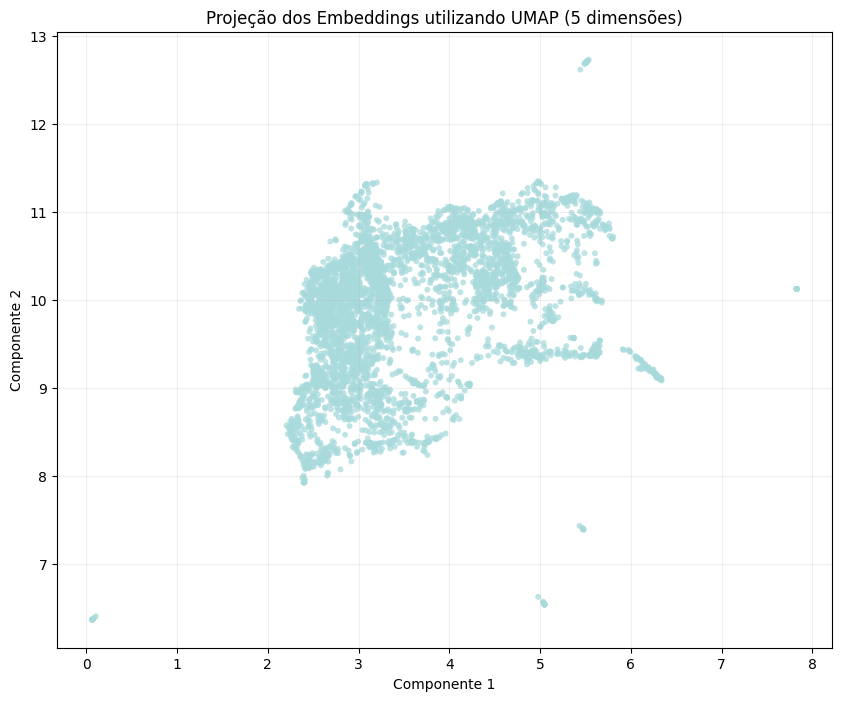

In [ ]:
embeddings_2d = umap_5.fit_transform(embeddings)

plt.figure(figsize=(10,8))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    s=18,
    color="#A8DADC",   # azul pastel
    alpha=0.75,
    edgecolors="none"
)

plt.title("Projeção dos Embeddings utilizando UMAP (5 dimensões)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.grid(alpha=0.2)

plt.show()

## UMAP 10 dimensões

In [ ]:
umap_10 = umap.UMAP(
    n_neighbors=13,
    n_components=10,
    metric="cosine",
    min_dist=0.0,
    random_state=42
)

embeddings_umap_10 = umap_10.fit_transform(embeddings)

print("Formato:", embeddings_umap_10.shape)

np.save("embeddings_umap_10.npy", embeddings_umap_10)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Formato: (4377, 10)


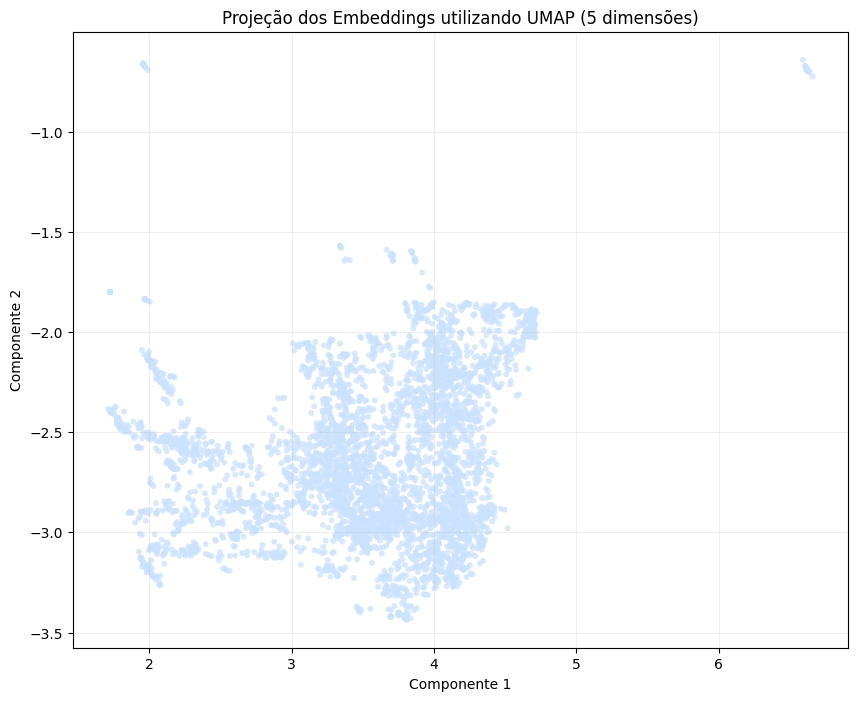

In [ ]:
embeddings_2d = umap_10.fit_transform(embeddings)

plt.figure(figsize=(10,8))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    s=18,
    color="#CBE2FE",
    alpha=0.75,
    edgecolors="none"
)

plt.title("Projeção dos Embeddings utilizando UMAP (5 dimensões)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.grid(alpha=0.2)

plt.show()

## UMAP 15 dimensões

In [ ]:
umap_15 = umap.UMAP(
    n_neighbors=13,
    n_components=15,
    metric="cosine",
    min_dist=0.0,
    random_state=42
)

embeddings_umap_15 = umap_15.fit_transform(embeddings)

print("Formato:", embeddings_umap_15.shape)

np.save("embeddings_umap_15.npy", embeddings_umap_15)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Formato: (4377, 15)


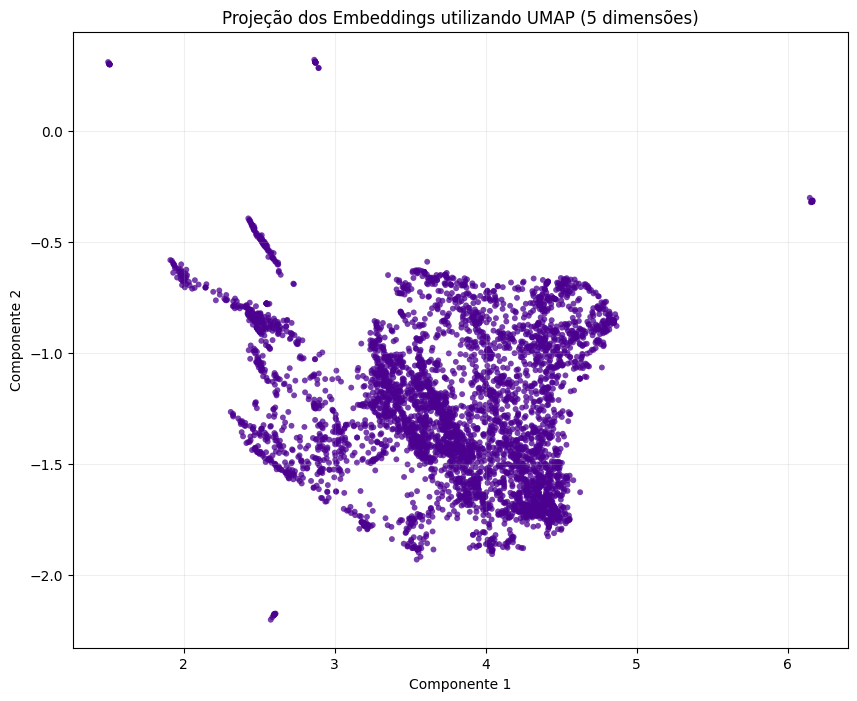

In [ ]:
embeddings_2d = umap_15.fit_transform(embeddings)

plt.figure(figsize=(10,8))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    s=18,
    color="#4B0090",
    alpha=0.75,
    edgecolors="none"
)

plt.title("Projeção dos Embeddings utilizando UMAP (5 dimensões)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.grid(alpha=0.2)

plt.show()

## Trustworthiness

A qualidade da redução de dimensionalidade foi avaliada por meio da métrica Trustworthiness, que mede o quanto as relações de vizinhança do espaço original foram preservadas após a projeção pelo UMAP. Valores próximos de 1 indicam maior preservação da estrutura local dos dados.

In [ ]:


score5 = trustworthiness(
    embeddings,
    embeddings_umap_5,
    n_neighbors=12
)

score10 = trustworthiness(
    embeddings,
    embeddings_umap_10,
    n_neighbors=12
)

score15 = trustworthiness(
    embeddings,
    embeddings_umap_15,
    n_neighbors=12
)

print(f"Trustworthiness (5D): {score5:.4f}")
print(f"Trustworthiness (10D): {score10:.4f}")
print(f"Trustworthiness (15D): {score15:.4f}")

Trustworthiness (5D): 0.9316
Trustworthiness (10D): 0.9343
Trustworthiness (15D): 0.9337


## Conclusão

Foram avaliadas três configurações do UMAP (5, 10 e 15 dimensões) utilizando a métrica Trustworthiness, que avalia o quanto a estrutura de vizinhança dos embeddings originais é preservada após a redução de dimensionalidade. Todas as configurações apresentaram valores próximos de 0,93, indicando boa preservação da estrutura dos dados. A configuração com 10 dimensões obteve o maior valor (0,9343).  

Como todos apresentaram bons valores, foi decidido que seriam feitas as clusterizações com os três UMAPs e então será analisado qual ficou melhor clusterizado.

#Clusterização com HDBSCAN

## 1- Função para executar o HDBSCAN

In [ ]:
def executar_hdbscan(embeddings_reduzidos,
                     min_cluster_size,
                     min_samples=None):

    modelo = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="manhattan",
        prediction_data=True
    )

    labels = modelo.fit_predict(embeddings_reduzidos)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    ruido = np.sum(labels == -1)

    percentual_ruido = (ruido / len(labels)) * 100

    # Calcula silhouette ignorando o ruído
    mascara = labels != -1

    if len(set(labels[mascara])) > 1:

        silhouette = silhouette_score(
            embeddings_reduzidos[mascara],
            labels[mascara]
        )

    else:

        silhouette = np.nan

    return labels, n_clusters, ruido, percentual_ruido, silhouette

## 2- Organizar os UMAP's

In [ ]:
embeddings_umap = {
    "UMAP 5D": embeddings_umap_5,
    "UMAP 10D": embeddings_umap_10,
    "UMAP 15D": embeddings_umap_15
}

## 3- Executar todos os testes



In [ ]:
resultados = []

labels_salvos = {}

for nome_umap, emb in embeddings_umap.items():

    print("="*60)
    print(nome_umap)
    print("="*60)

    for tamanho in [29,46,71]:

        labels, clusters, ruido, perc_ruido, silhouette = executar_hdbscan(
            emb,
            min_cluster_size=tamanho
        )

        chave = f"{nome_umap}_cluster_{tamanho}"

        labels_salvos[chave] = labels

        resultados.append({

            "UMAP": nome_umap,

            "min_cluster_size": tamanho,

            "Clusters": clusters,

            "Ruído": ruido,

            "% Ruído": round(perc_ruido,2),

            "Silhouette": round(silhouette,4)

        })

        print(
            f"min_cluster_size={tamanho}"
            f" | Clusters={clusters}"
            f" | Ruído={perc_ruido:.2f}%"
            f" | Silhouette={silhouette:.4f}"
        )

UMAP 5D
min_cluster_size=29 | Clusters=9 | Ruído=21.75% | Silhouette=0.4557
min_cluster_size=46 | Clusters=4 | Ruído=3.31% | Silhouette=0.2545
min_cluster_size=71 | Clusters=7 | Ruído=26.07% | Silhouette=0.4682
UMAP 10D
min_cluster_size=29 | Clusters=4 | Ruído=2.06% | Silhouette=0.2675
min_cluster_size=46 | Clusters=4 | Ruído=2.26% | Silhouette=0.2685
min_cluster_size=71 | Clusters=3 | Ruído=3.84% | Silhouette=0.3025
UMAP 15D
min_cluster_size=29 | Clusters=4 | Ruído=2.99% | Silhouette=0.2802
min_cluster_size=46 | Clusters=4 | Ruído=2.76% | Silhouette=0.2794
min_cluster_size=71 | Clusters=3 | Ruído=4.71% | Silhouette=0.3038


## 4- Tabela comparativa

In [ ]:
comparacao = pd.DataFrame(resultados)

comparacao = comparacao.sort_values(
    by="Silhouette",
    ascending=False
)

comparacao

,UMAP,min_cluster_size,Clusters,Ruído,% Ruído,Silhouette
2,UMAP 5D,71,7,1141,26.07,0.4682
0,UMAP 5D,29,9,952,21.75,0.4557
8,UMAP 15D,71,3,206,4.71,0.3038
5,UMAP 10D,71,3,168,3.84,0.3025
6,UMAP 15D,29,4,131,2.99,0.2802
7,UMAP 15D,46,4,121,2.76,0.2794
4,UMAP 10D,46,4,99,2.26,0.2685
3,UMAP 10D,29,4,90,2.06,0.2675
1,UMAP 5D,46,4,145,3.31,0.2545


In [ ]:
melhor = comparacao.iloc[0]

print("Melhor configuração encontrada:\n")

display(melhor)

Melhor configuração encontrada:



,2
UMAP,UMAP 5D
min_cluster_size,71
Clusters,7
Ruído,1141
% Ruído,26.07
Silhouette,0.4682


## 5- Conclusão da Clusterização

### 🧪 Exploração de Hiperparâmetros e Seleção de Modelos

Durante os experimentos com o **HDBSCAN**, foram testadas diferentes combinações de parâmetros, variando a dimensionalidade do **UMAP (5, 10 e 15)** e o parâmetro `min_cluster_size`. Inicialmente, observou-se uma grande variação no número de clusters, na porcentagem de ruído e no índice de *Silhouette*.

---

### 🎯 Definição do Escopo de Análise (7 vs. 9 Clusters)

Após a etapa exploratória, optou-se por concentrar a análise nas configurações que produziram **7 e 9 clusters**, pois apresentaram o melhor equilíbrio entre qualidade quantitativa e interpretabilidade dos agrupamentos.

A escolha baseou-se nos seguintes critérios:

* **🚫 Evitando Grupos Muito Amplos (2 a 4 clusters):** Configurações com pouquíssimos clusters geravam grupos muito genéricos e heterogêneos, dificultando a identificação de temas específicos e nichados do debate.
* **📈 Maximização do Silhouette:** As configurações selecionadas apresentaram os maiores valores de *Silhouette Score* dentre todos os cenários testados, indicando uma melhor separação geométrica entre os grupos.

---

### 🔍 Trade-off Qualitativo vs. Quantitativo

Embora a configuração com 9 clusters tenha produzido uma menor porcentagem de ruído, a configuração com 7 clusters apresentou agrupamentos **semanticamente mais coesos** durante a inspeção qualitativa dos comentários. Essa coesão facilita a interpretação humana e otimiza a etapa posterior de rotulação automática utilizando modelos de linguagem (LLM).

> 📌 **Conclusão da Etapa:** Ambas as configurações (7 e 9 clusters) foram consideradas as mais adequadas para representar os principais temas do *corpus*. Elas viabilizam uma comparação rica entre uma **abordagem mais detalhada (9 clusters)** e outra **mais consolidada e interpretável (7 clusters)**.

# Avaliação HDBSCAN (Silhouette + análise qualitativa)

Aqui nos comparamos a clusterização com 7 e 9 clusters.

In [ ]:
labels_salvos

{'UMAP 5D_cluster_29': array([ 7,  6, -1, ...,  8,  7, -1]),
 'UMAP 5D_cluster_46': array([2, 2, 2, ..., 2, 2, 2]),
 'UMAP 5D_cluster_71': array([ 5,  2,  4, ...,  6,  5, -1]),
 'UMAP 10D_cluster_29': array([3, 3, 3, ..., 3, 3, 3]),
 'UMAP 10D_cluster_46': array([3, 3, 3, ..., 3, 3, 3]),
 'UMAP 10D_cluster_71': array([2, 2, 2, ..., 2, 2, 2]),
 'UMAP 15D_cluster_29': array([3, 3, 3, ..., 3, 3, 3]),
 'UMAP 15D_cluster_46': array([3, 3, 3, ..., 3, 3, 3]),
 'UMAP 15D_cluster_71': array([2, 2, 2, ..., 2, 2, 2])}

## 1- Clusterização UMAP 5 dimensões com tamanho mínimo de 29 documentos por cluster  
##(9 clusters)

In [ ]:
df_limpo["cluster"] = labels_salvos["UMAP 5D_cluster_29"]

for cluster in sorted(df_limpo["cluster"].unique()):
    print("="*70)
    print(f"CLUSTER {cluster}")
    print("="*70)

    exemplos = (
        df_limpo[df_limpo["cluster"] == cluster]
        ["comentario_limpo"]
        .sample(min(10, len(df_limpo[df_limpo["cluster"] == cluster])),
                random_state=42)
    )

    for comentario in exemplos:
        print("-", comentario)

CLUSTER -1
- derruba por causa de uma motosiata kkkkkkkkkk
- essa música de fundo parece um "bgm" (background music) de jogos como dragon ball z kakarot.
- quero ver o metaforando do nesse debate ai hhahaahaha
- 03:34:52 lei maria da paz? kakakakakakakakakakakakakak
- “tem que ter o hábito de doar” doar para campanha política? se eu estivesse pensando em votar nela, já esqueci.
- "meu povo pereçe por falta de co conhecimento". as pessoas se iludem muito fácil e acreditam em palavras bonitas e pela aparência. é impressionante como as pessoas ingnoram os fatos, acreditam em mentiras e esquecem as coisas rapidamente, e o pior de tudo, acreditam ainda em democracia, a democracia é e foi sempre feita pela o sistema(a elite global) e nunca feita pelo o povo nós o cidadão de bem trabalhador. são eles que tocam a música no mundo infelizmente, em outras palavras a elite que coloca quem eles querem no poder por meio de manipulação e lacração mental.
- vejo fala do orçamento secreto mas tds os pa

### 1.1- Quantidade de documentos por cluster

In [ ]:
contagem_clusters = (
    df_limpo["cluster"]
    .value_counts()
    .sort_index()
)

print(contagem_clusters)

cluster
-1     952
 0      50
 1      72
 2     190
 3     403
 4     354
 5     216
 6     529
 7    1190
 8     421
Name: count, dtype: int64


### 1.2- Análise de cada cluster

A análise foi feita manualmente, salvando e baixando um .csv para cada cluster

In [ ]:
# Seleciona apenas os comentários do cluster específico(0,1,2,3,4,5,6 ou 7)
cluster = df_limpo[df_limpo["cluster"] == 7]

print(f"Quantidade de comentários: {len(cluster)}")

# Salva em CSV para melhor análise
cluster.to_csv(
    "cluster.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo com sucesso!")

Quantidade de comentários: 1190
Arquivo salvo com sucesso!


### 1.3- Visualização dos Clusters

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


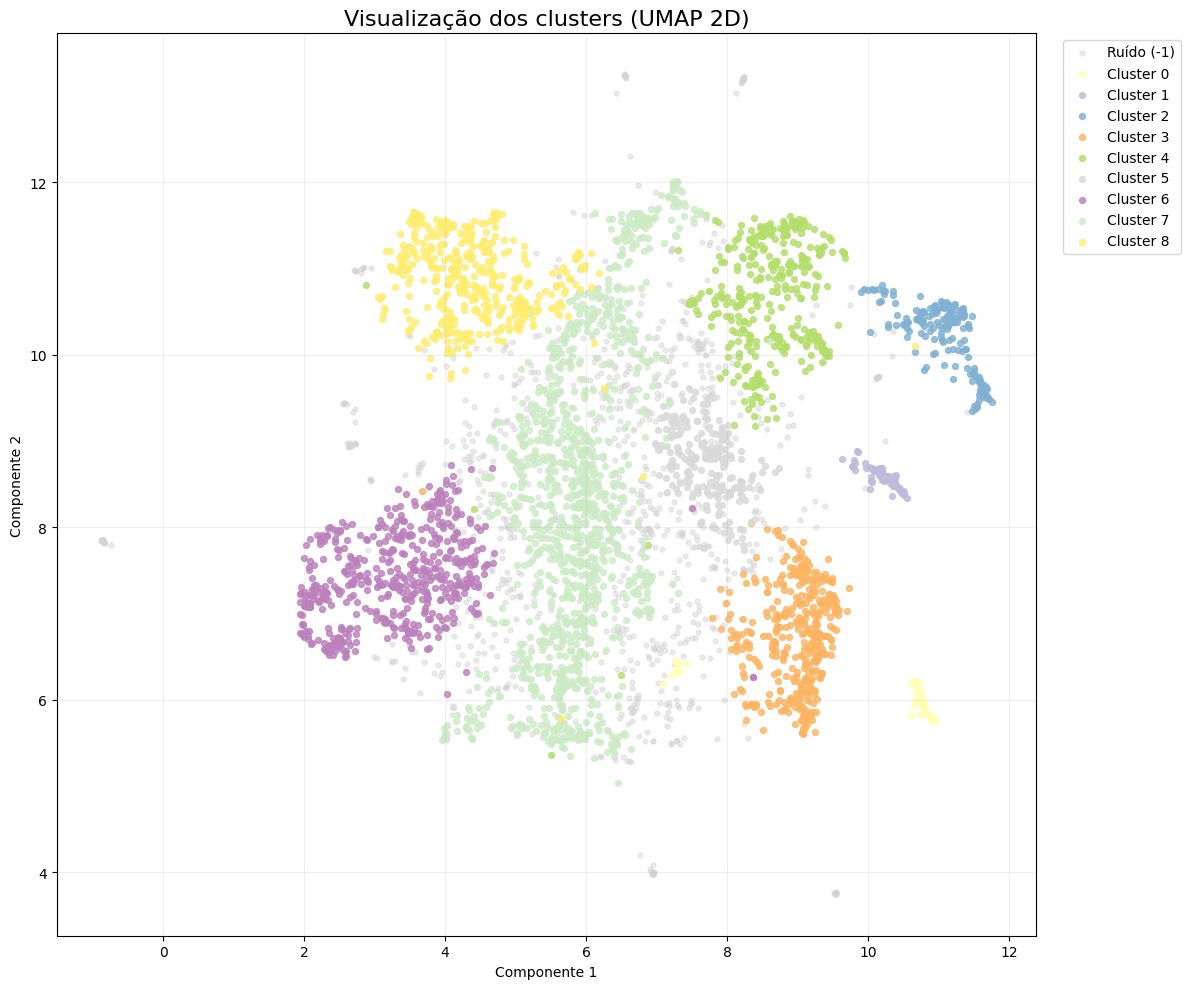

In [ ]:
umap_visual = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=13,
    random_state=42
)

embeddings_visual = umap_visual.fit_transform(embeddings)

plt.figure(figsize=(12,10))

# Cores para os clusters
clusters = sorted(df_limpo["cluster"].unique())

cores = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

for cor, cluster in zip(cores, clusters):

    mascara = df_limpo["cluster"] == cluster

    if cluster == -1:
        plt.scatter(
            embeddings_visual[mascara,0],
            embeddings_visual[mascara,1],
            s=12,
            c="lightgray",
            alpha=0.45,
            label="Ruído (-1)"
        )

    else:

        plt.scatter(
            embeddings_visual[mascara,0],
            embeddings_visual[mascara,1],
            s=18,
            color=cor,
            alpha=0.8,
            label=f"Cluster {cluster}"
        )

plt.title("Visualização dos clusters (UMAP 2D)", fontsize=16)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

### 1.4 Resumo dos Clusters e Tema predominante de cada um.

Aqui nos, manualmente, após a análise dos comentários de cada cluster decidimos um tema que representava predominantemente o cluster.

In [ ]:
resumo = (
    df_limpo["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumo.columns = [
    "Cluster",
    "Quantidade de Comentários"
]

resumo["Percentual (%)"] = (
    resumo["Quantidade de Comentários"]
    / len(df_limpo)
    *100
).round(2)

temas = {
    -1: "Ruído / comentários diversos",
    0: "Pablo Marçal e candidatos ausentes",
    1: "Felipe D'Ávila",
    2: "Timestamps e momentos do debate",
    3: "Band e organização do debate",
    4: "Simone Tebet e Soraya",
    5: "Política e debate geral",
    6: "Jair Bolsonaro",
    7: "Lula e eleições",
    8: "Ciro Gomes"
}

resumo["Tema"] = resumo["Cluster"].map(temas)

display(resumo)

,Cluster,Quantidade de Comentários,Percentual (%),Tema
0,-1,952,21.75,Ruído / comentários diversos
1,0,50,1.14,Pablo Marçal e candidatos ausentes
2,1,72,1.64,Felipe D'Ávila
3,2,190,4.34,Timestamps e momentos do debate
4,3,403,9.21,Band e organização do debate
5,4,354,8.09,Simone Tebet e Soraya
6,5,216,4.93,Política e debate geral
7,6,529,12.09,Jair Bolsonaro
8,7,1190,27.19,Lula e eleições
9,8,421,9.62,Ciro Gomes


### 1.5- Análise

#### Configuração e Resultados da Clusterização

| Componente / Métrica | Configuração / Resultado |
| :--- | :--- |
| **Dimensões do UMAP** | 5D |
| **n_neighbors (UMAP)** | 13 |
| **min_cluster_size (HDBSCAN)** | 29 |
| **Quantidade de Clusters** | 9 principais *(além do grupo de ruído -1)* |
| **Silhouette Score** | **0,4557** |
| **Percentual de Ruído** | 21,75% |

---

##### 🔍 Análise do Grupo de Ruído (Cluster -1)

Embora aproximadamente um quinto dos comentários tenha sido classificado como ruído (cluster = -1), esse comportamento é esperado no HDBSCAN. O algoritmo identifica como ruído os comentários que não apresentam similaridade suficiente com nenhum grupo específico, evitando forçar documentos muito diferentes a pertencerem a um cluster. Em comentários de redes sociais, esse percentual é considerado aceitável devido à grande presença de mensagens curtas, emojis, piadas, spam, timestamps e opiniões muito particulares.

O cluster -1 (ruído) reuniu comentários bastante heterogêneos, incluindo mensagens muito curtas, piadas, comentários extremamente longos, trechos isolados, emojis e textos que não apresentaram similaridade suficiente com os demais grupos. Essa característica reforça a capacidade do HDBSCAN de evitar agrupamentos artificiais.

---

####  📌 Inspeção Qualitativa dos Clusters

A inspeção qualitativa mostrou que os clusters apresentam alta coerência semântica, agrupando comentários por assunto ou personagem político, e não apenas por similaridade lexical. Alguns exemplos observados foram:

* **Cluster 0:** comentários relacionados principalmente à ausência de candidatos no debate, especialmente Pablo Marçal, além de menções a Ricardo Boechat, Cabo Daciolo e Janones.
* **Cluster 1:** comentários concentrados no candidato Felipe D'Ávila, contendo elogios, críticas e discussões sobre suas propostas.
* **Cluster 2:** comentários contendo principalmente timestamps, observações sobre momentos específicos do vídeo e referências ao andamento do debate.
* **Cluster 3:** comentários direcionados à organização do debate, elogiando ou criticando a Band, a transmissão e os mediadores.
* **Cluster 4:** comentários relacionados principalmente às candidatas Simone Tebet e Soraya Thronicke, reunindo elogios, críticas e discussões sobre seus posicionamentos.
* **Cluster 5:** comentários mais gerais sobre o cenário político, qualidade do debate, democracia e propostas dos candidatos.
* **Cluster 6:** comentários fortemente relacionados ao Jair Bolsonaro, contendo manifestações de apoio ou rejeição ao candidato.
* **Cluster 7:** comentários predominantemente envolvendo Lula, comparações entre governos e discussões eleitorais.
* **Cluster 8:** comentários focados principalmente em Ciro Gomes, além de comparações entre diferentes candidatos e discussões políticas mais amplas.

---

#### 🎯 Conclusão e Próximas Etapas

Os resultados demonstram que a combinação Sentence Transformers + UMAP + HDBSCAN foi capaz de identificar automaticamente diferentes tópicos de discussão presentes nos comentários do vídeo. Em vez de agrupar apenas comentários positivos e negativos, o algoritmo organizou os documentos de acordo com os principais temas debatidos, produzindo grupos semanticamente consistentes que poderão ser utilizados na próxima etapa do trabalho, onde um LLM será empregado para rotular automaticamente cada cluster, extrair palavras-chave e gerar insights acionáveis para o gestor responsável pelo corpus.

## 2-Clusterização UMAP 5 dimensões com tamanho mínimo de 71 documentos por cluster  
##(7 clusters)

In [ ]:
df_limpo["cluster"] = labels_salvos["UMAP 5D_cluster_71"]

for cluster in sorted(df_limpo["cluster"].unique()):
    print("="*70)
    print(f"CLUSTER {cluster}")
    print("="*70)

    exemplos = (
        df_limpo[df_limpo["cluster"] == cluster]
        ["comentario_limpo"]
        .sample(min(10, len(df_limpo[df_limpo["cluster"] == cluster])),
                random_state=42)
    )

    for comentario in exemplos:
        print("-", comentario)

CLUSTER -1
- esse safado ladrão de nove dedos usa os pobres toda vez que o bicho pega para o lado dele, estão sendo usados de fantoches por esse bandido picareta
- felipe , você será um ótimo cabo eleitoral do presidente bolsonaro!🤛o primeiro carregamento de milho rumo ao porto de santos já aconteceu!
- um circo e nos somos os palhaços.
- porque não houve logo a tela inteira na primeira pergunta a ciro? foi erro da direção ou outro problema?
- este candidato só gosta de privatização e privatização só ver lucros e esquece os direitos do cidadão
- fora bolsonaro. agora e lula
- parei no todos e todas
- alemanha esta faltando tudo
- essa soraia está com nada
- cnta. soraia . discorda do ex presindente. lula. e ? ex presidente.lula. n saida. dele .a quilomia. do pais .que foi de 7 .e/6 meio.? isso 300/ 30 /milhóė .por pobres brasileiros. se dividir pra cada. um pessoa. ? quanto ė que dar. ? cepeir oouvi sim corupisåo eleisåo. nna nnt. 3h por sento. cilo gome. e o prizidente busomario. . na

### 2.1- Quantidade de documentos por cluster

In [ ]:
contagem_clusters = (
    df_limpo["cluster"]
    .value_counts()
    .sort_index()
)

print(contagem_clusters)

cluster
-1    1141
 0      72
 1     188
 2     579
 3     385
 4     293
 5    1352
 6     367
Name: count, dtype: int64


### 2.2- Análise de cada cluster

A análise foi feita manualmente, salvando e baixando um .csv para cada cluster

In [ ]:
# Seleciona apenas os comentários do cluster específico(0,1,2,3,4,5,6)
cluster = df_limpo[df_limpo["cluster"] == 5]

print(f"Quantidade de comentários: {len(cluster)}")

# Salva em CSV para melhor análise
cluster.to_csv(
    "cluster.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo com sucesso!")

Quantidade de comentários: 1352
Arquivo salvo com sucesso!


### 2.3- Visualização dos Clusters

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


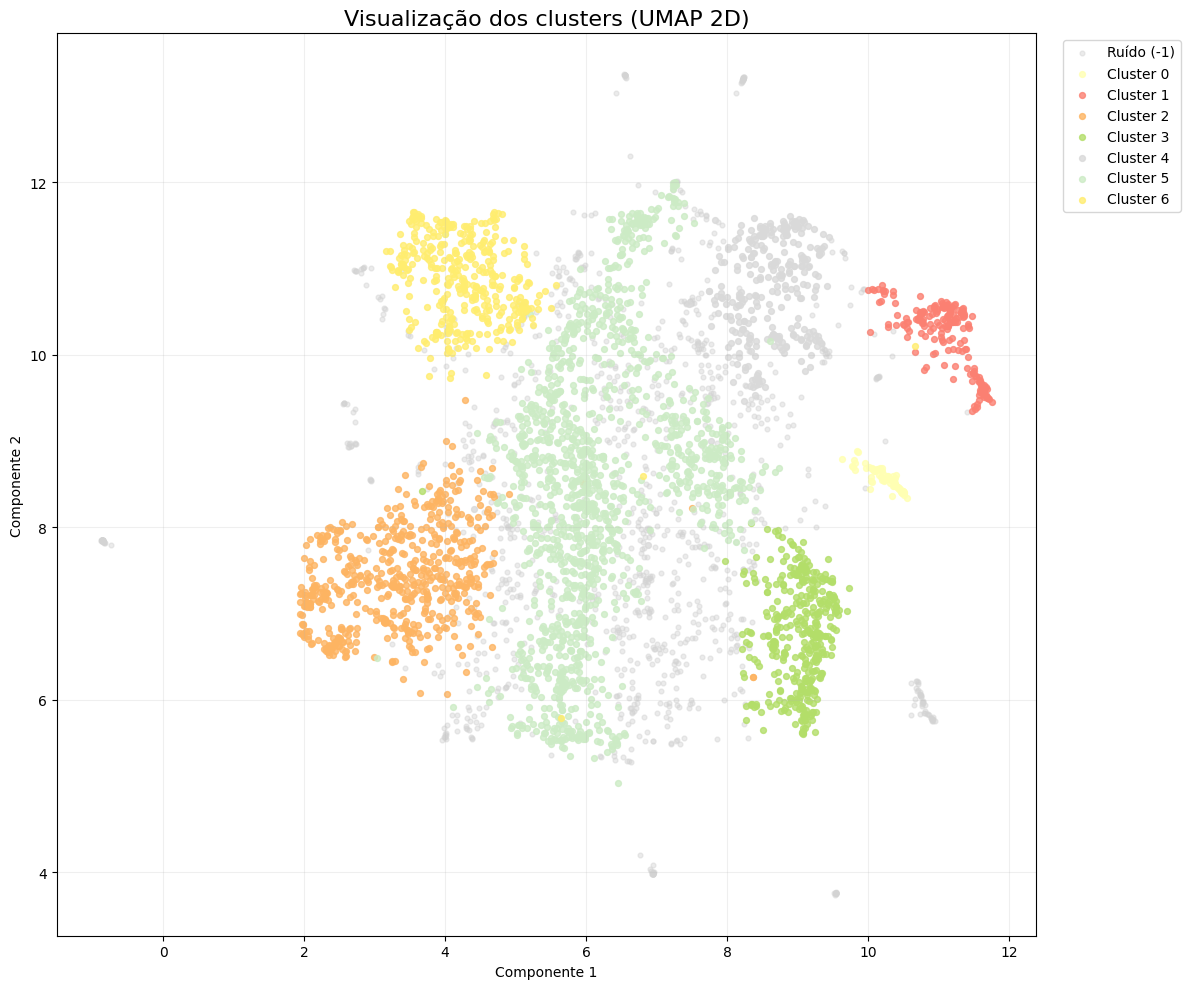

In [ ]:
umap_visual = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=13,
    random_state=42
)

embeddings_visual = umap_visual.fit_transform(embeddings)

plt.figure(figsize=(12,10))

# Cores para os clusters
clusters = sorted(df_limpo["cluster"].unique())

cores = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

for cor, cluster in zip(cores, clusters):

    mascara = df_limpo["cluster"] == cluster

    if cluster == -1:
        plt.scatter(
            embeddings_visual[mascara,0],
            embeddings_visual[mascara,1],
            s=12,
            c="lightgray",
            alpha=0.45,
            label="Ruído (-1)"
        )

    else:

        plt.scatter(
            embeddings_visual[mascara,0],
            embeddings_visual[mascara,1],
            s=18,
            color=cor,
            alpha=0.8,
            label=f"Cluster {cluster}"
        )

plt.title("Visualização dos clusters (UMAP 2D)", fontsize=16)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

### 2.4 Resumo dos Clusters e Tema predominante de cada um.

Aqui nos, manualmente, após a análise dos comentários de cada cluster decidimos um tema que representava predominantemente o cluster.

In [ ]:
resumo = (
    df_limpo["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumo.columns = [
    "Cluster",
    "Quantidade de Comentários"
]

resumo["Percentual (%)"] = (
    resumo["Quantidade de Comentários"]
    / len(df_limpo)
    *100
).round(2)

temas = {
    -1: "Ruído / comentários diversos",
    0: "Felipe D'Ávila",
    1: "Timestamps e momentos do debate",
    2: "Jair Bolsonaro",
    3: "Band e organização do debate",
    4: "Simone Tebet e Soraya",
    5: "Lula",
    6: "Ciro Gomes"
}

resumo["Tema"] = resumo["Cluster"].map(temas)

display(resumo)

,Cluster,Quantidade de Comentários,Percentual (%),Tema
0,-1,1141,26.07,Ruído / comentários diversos
1,0,72,1.64,Felipe D'Ávila
2,1,188,4.30,Timestamps e momentos do debate
3,2,579,13.23,Jair Bolsonaro
4,3,385,8.80,Band e organização do debate
5,4,293,6.69,Simone Tebet e Soraya
6,5,1352,30.89,Lula
7,6,367,8.38,Ciro Gomes


### 2.5- Análise

#### Configuração de Maior Desempenho

Nesta configuração, foi utilizado o **UMAP** para redução de dimensionalidade combinado com o algoritmo de densidade **HDBSCAN**. O modelo obteve o **maior valor de Silhouette Score** observado durante toda a bateria de experimentos realizados.

##### ⚙️ Hiperparâmetros e Métricas Obtidas

| Componente / Métrica | Configuração / Resultado |
| :--- | :--- |
| **Dimensões do UMAP** | 5D |
| **n_neighbors (UMAP)** | 13 |
| **min_cluster_size (HDBSCAN)** | 71 |
| **Quantidade de Clusters** | 7 principais *(além do grupo de ruído -1)* |
| **Silhouette Score** | **0,4682** |
| **Percentual de Ruído** | 26,07% |

> 💡 **Nota sobre o Ruído:** O percentual de documentos classificados como ruído foi de 26,07%, valor considerado aceitável para tarefas de mineração de textos envolvendo comentários de redes sociais.

O aumento do *Silhouette Score* indica que os grupos encontrados apresentam maior separação entre si e maior similaridade interna, formando clusters mais homogêneos. Em contrapartida, o aumento do tamanho mínimo do cluster reduziu a quantidade de grupos encontrados e aumentou ligeiramente o percentual de comentários classificados como ruído.

Este comportamento é esperado no HDBSCAN, pois critérios mais rígidos para a formação dos grupos tendem a descartar documentos que não pertencem claramente a nenhum tema específico.

---

##### 🔍 Análise Qualitativa dos Tópicos Encontrados

A análise qualitativa dos comentários mostrou que os clusters representam temas bastante bem definidos dentro do ecossistema do debate:

* **🔹 Cluster 0 – Felipe D'Ávila:** Concentrou comentários relacionados ao candidato Felipe D'Ávila, reunindo elogios, críticas, discussões sobre suas propostas econômicas e comparações com outros candidatos.
* **🔹 Cluster 1 – Timestamps e momentos específicos do debate:** Agrupou comentários contendo marcações de tempo (*timestamps*), reações a momentos específicos do debate e observações sobre acontecimentos durante a transmissão. Esse comportamento demonstra que o modelo conseguiu identificar um padrão textual característico desse tipo de comentário.
* **🔹 Cluster 2 – Jair Bolsonaro:** Reuniu comentários predominantemente relacionados ao então presidente Jair Bolsonaro, contendo manifestações de apoio, críticas, pedidos de reeleição e comparações com outros candidatos.
* **🔹 Cluster 3 – Debate e transmissão da Band:** Concentrou comentários voltados à qualidade da transmissão, atuação dos jornalistas, organização do debate e avaliações da emissora Band.
* **🔹 Cluster 4 – Simone Tebet e Soraya Thronicke:** Agrupou comentários referentes às duas candidatas, incluindo elogios, críticas, comparações e discussões sobre a participação feminina no debate presidencial.
* **🔹 Cluster 5 – Lula :** Reuniu comentários envolvendo Luiz Inácio Lula da Silva, corrupção, educação, religião, Partido dos Trabalhadores , funcionando como um cluster de críticas ou apoio ao Lula.
* **🔹 Cluster 6 – Ciro Gomes:** Concentrou comentários relacionados ao candidato Ciro Gomes, contendo elogios, críticas, comparações com Lula e Bolsonaro e discussões sobre suas propostas, principalmente na área da educação.

##### 🗑️ Tratamento de Outliers
* **⚠️ Cluster -1 (Ruído):** Reuniu comentários bastante heterogêneos, incluindo mensagens muito curtas, opiniões isoladas, textos excessivamente longos, comentários pouco relacionados ao restante do *corpus* e mensagens cuja similaridade semântica não foi suficiente para integrá-las a um grupo específico. Esse comportamento reforça uma das principais características do HDBSCAN: identificar automaticamente documentos considerados *outliers*, evitando criar agrupamentos artificiais.

---

##### 📌 Conclusão

De maneira geral, observa-se que o algoritmo foi capaz de separar automaticamente os comentários em grandes tópicos de discussão presentes no debate presidencial.

Em vez de organizar os documentos apenas por polaridade (comentários positivos ou negativos), a clusterização identificou grupos relacionados aos principais candidatos, à qualidade da transmissão e a diferentes aspectos do debate, evidenciando a capacidade dos ***embeddings* contextuais** em capturar a real similaridade semântica entre os textos.

# Clusterização com K-Means

O enunciado pede a comparação de **pelo menos dois modelos de agrupamento**. Até aqui usamos o **HDBSCAN** (baseado em densidade). Agora aplicamos o **K-Means** (particional) sobre a mesma representação UMAP, para contrastar duas famílias diferentes de algoritmo:

| | HDBSCAN (densidade) | K-Means (particional) |
|---|---|---|
| Nº de clusters | descobre sozinho | definido por nós (k) |
| Ruído | sim (rótulo -1) | não — todo ponto entra num grupo |
| Forma dos grupos | arbitrária | esférica (em torno de centróides) |

A comparação é feita pela **silhouette** e pela inspeção qualitativa — o baseline exigido antes de chamar o LLM.

## 1- Definir o K e analisar a Silhouette

In [ ]:
# Usamos a representação UMAP de melhor clusterização no HDBSCAN.
emb_trabalho = embeddings_umap_5

# Varredura de k: testamos uma faixa em torno do número de grupos do HDBSCAN.
print("Varredura de k (K-Means) por silhouette:\n")
resultados_kmeans = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    rotulos = km.fit_predict(emb_trabalho)
    sil = silhouette_score(emb_trabalho, rotulos)
    resultados_kmeans.append({"k": k, "silhouette": round(sil, 4)})
    print(f"  k={k:2d} | silhouette={sil:.4f}")

melhor_k = max(resultados_kmeans, key=lambda r: r["silhouette"])["k"]
print(f"\nMelhor k pela silhouette: {melhor_k}")

Varredura de k (K-Means) por silhouette:

  k= 2 | silhouette=0.2650
  k= 3 | silhouette=0.2866
  k= 4 | silhouette=0.3297
  k= 5 | silhouette=0.3714
  k= 6 | silhouette=0.3887
  k= 7 | silhouette=0.4051
  k= 8 | silhouette=0.4180
  k= 9 | silhouette=0.4187
  k=10 | silhouette=0.4380

Melhor k pela silhouette: 10


## 2- Rodar o K-means e comparar com HDBSCAN

In [ ]:
# Roda o K-Means com o melhor k e guarda os rótulos.
kmeans = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(emb_trabalho)
sil_kmeans = silhouette_score(emb_trabalho, labels_kmeans)

# Recupera o melhor resultado do HDBSCAN (a tabela 'comparacao' já está ordenada
# por Silhouette em ordem decrescente, então a primeira linha é a melhor).
melhor_hdbscan = comparacao.iloc[0]

print("Comparação entre os dois modelos de agrupamento:\n")
tabela_modelos = pd.DataFrame([
    {"Modelo": "HDBSCAN (densidade)",
     "Config": f"{melhor_hdbscan['UMAP']} / min_cluster_size={int(melhor_hdbscan['min_cluster_size'])}",
     "Nº clusters": int(melhor_hdbscan["Clusters"]),
     "Silhouette": float(melhor_hdbscan["Silhouette"]),
     "% Ruído": float(melhor_hdbscan["% Ruído"])},
    {"Modelo": "K-Means (particional)",
     "Config": f"UMAP 10D / k={melhor_k}",
     "Nº clusters": melhor_k,
     "Silhouette": round(float(sil_kmeans), 4),
     "% Ruído": 0.0},
])
display(tabela_modelos)

Comparação entre os dois modelos de agrupamento:



,Modelo,Config,Nº clusters,Silhouette,% Ruído
0,HDBSCAN (densidade),UMAP 5D / min_cluster_size=71,7,0.4682,26.07
1,K-Means (particional),UMAP 10D / k=10,10,0.4380,0.00


# Escolha da Configuração Final

Embora a configuração com 9 clusters apresentasse um percentual menor de ruído, optou-se pela configuração com 7 clusters por apresentar o maior Silhouette Score obtido (0,4682) e, principalmente, por produzir agrupamentos semanticamente mais coesos. Durante a inspeção qualitativa observou-se que os sete clusters correspondiam a temas bem definidos do debate, facilitando sua interpretação e a etapa posterior de rotulação automática com LLM.  

> 📌 **Conclusão Metodológica:** Privilegiou-se uma solução que oferecesse maior riqueza analítica e granularidade para o negócio, sem comprometer significativamente a qualidade estatística da separação dos agrupamentos.

In [ ]:
df_limpo["cluster"] = labels_salvos["UMAP 5D_cluster_71"]

In [ ]:
modelo_principal = "HDBSCAN"
chave = f"{melhor_hdbscan['UMAP']}_cluster_{int(melhor_hdbscan['min_cluster_size'])}"
df_limpo["cluster_final"] = labels_salvos[chave]

print(f"Modelo principal escolhido para rotulagem: {modelo_principal}\n")
print("Distribuição de comentários por cluster:")
print(df_limpo["cluster_final"].value_counts().sort_index())

Modelo principal escolhido para rotulagem: HDBSCAN

Distribuição de comentários por cluster:
cluster_final
-1    1141
 0      72
 1     188
 2     579
 3     385
 4     293
 5    1352
 6     367
Name: count, dtype: int64


O modelo principal ficou o HDBSCAN usando "UMAP 5D_cluster_71" com 7 clusters.

#LLM + Pydantic

O objetivo é usar o LLM como **componente confiável de software**.Exigimos que o modelo devolva um **JSON que obedeça a um schema Pydantic**; se violar, **re-tentamos reenviando o erro**, e se esgotar, registramos **falha explícita**.

Para enriquecer a análise (comentário de debate não se resume a "bom/ruim"), o schema captura, por cluster:
1. **Tema** livre + **categoria temática** do debate (economia, saúde, segurança, educação, corrupção, outros);
2. **Sentimento** predominante (positivo / negativo / neutro / misto);
3. **Inclinação político-ideológica EXPRESSA no conjunto** (esquerda / direita / centro / não-identificável) — ver a nota metodológica na seção de Tema e Polarização.

O cliente é **provider-agnóstico**: usa o **Gemini** se houver chave, ou um **simulador offline** determinístico para rodar sem chave.

## 1- Conectar a API do Gemini

In [ ]:
try:
    import google.generativeai as genai
    GEMINI_DISPONIVEL = True
except ImportError:
    GEMINI_DISPONIVEL = False
    print("google-generativeai não instalado — será usado o simulador offline.")
    print("Para usar o Gemini real, rode:  !pip install -q google-generativeai")
API_KEY = getpass("Digite sua chave da API Gemini: ")
# Para usar o Gemini, defina a chave via variável de ambiente.
# NÃO deixe a chave escrita no notebook ao subir para o Git!
os.environ["GEMINI_API_KEY"] = API_KEY

Digite sua chave da API Gemini: ··········


## 2- Definindo o Schema do *Pydantic*

In [ ]:

class Sentimento(str, Enum):
    POSITIVO = "positivo"; NEGATIVO = "negativo"; NEUTRO = "neutro"; MISTO = "misto"


class TemaDebate(str, Enum):
    """Eixos temáticos típicos de um debate presidencial brasileiro."""
    ECONOMIA = "economia"
    SAUDE = "saude"
    SEGURANCA = "seguranca"
    EDUCACAO = "educacao"
    CORRUPCAO = "corrupcao"
    OUTROS = "outros"


class AlinhamentoExpresso(str, Enum):
    """
    Posição ideológica EXPRESSA NO TEXTO do conjunto (não um rótulo de pessoa).
    'nao_identificavel' é o caso mais comum e honesto para texto curto.
    """
    ESQUERDA = "esquerda"
    DIREITA = "direita"
    CENTRO = "centro"
    NAO_IDENTIFICAVEL = "nao_identificavel"


class RotuloCluster(BaseModel):
    model_config = ConfigDict(extra="forbid")

    tema: str = Field(..., min_length=3, max_length=70,
                      description="Assunto central do cluster, em poucas palavras")
    categoria_tema: TemaDebate = Field(..., description="Eixo temático do debate")
    sentimento_predominante: Sentimento = Field(..., description="Sentimento dominante")
    intensidade: float = Field(..., ge=0.0, le=1.0,
                      description="Consistência/força do sentimento (0 a 1)")
    alinhamento_expresso: AlinhamentoExpresso = Field(...,
                      description="Inclinação expressa no conjunto (não na pessoa)")
    confianca_alinhamento: float = Field(..., ge=0.0, le=1.0,
                      description="Confiança do alinhamento; baixa => tratar como ruído")
    palavras_caracteristicas: list[str] = Field(..., min_length=2, max_length=8)
    resumo: str = Field(..., min_length=15, max_length=400)
    justificativa: str = Field(..., min_length=10, max_length=300)

    @field_validator("palavras_caracteristicas")
    @classmethod
    def _sem_vazias(cls, v):
        limpa = [p.strip() for p in v if p and p.strip()]
        if not limpa:
            raise ValueError("palavras_caracteristicas não pode conter apenas vazios")
        return limpa


class InsightAcionavel(BaseModel):
    model_config = ConfigDict(extra="forbid")
    titulo: str = Field(..., min_length=5, max_length=90)
    descricao: str = Field(..., min_length=20, max_length=400)
    acao_recomendada: str = Field(..., min_length=10, max_length=300)
    evidencia: str = Field(..., min_length=5, max_length=200)


class PainelInsights(BaseModel):
    model_config = ConfigDict(extra="forbid")
    insights: list[InsightAcionavel] = Field(..., min_length=3, max_length=3)


def schema_para_prompt(modelo):
    return json.dumps(modelo.model_json_schema(), ensure_ascii=False, indent=2)

print("Schemas:", [c.__name__ for c in (Sentimento, TemaDebate, AlinhamentoExpresso,
                                        RotuloCluster, InsightAcionavel, PainelInsights)])

Schemas: ['Sentimento', 'TemaDebate', 'AlinhamentoExpresso', 'RotuloCluster', 'InsightAcionavel', 'PainelInsights']


## 3- Definindo o Simulador Offline e a Extração de Json

In [ ]:
# ============================================================
# EXTRAÇÃO DE JSON + SIMULADOR OFFLINE (tema + alinhamento)
# ============================================================
def extrair_json(texto):
    m = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", texto, re.DOTALL)
    if m:
        return json.loads(m.group(1))
    m = re.search(r"\{.*\}", texto, re.DOTALL)
    if m:
        return json.loads(m.group(0))
    raise ValueError("Nenhum JSON encontrado na resposta do modelo")


def estimar_tokens(texto):
    return max(1, len(texto) // 4)


_POS = {"melhor","apoio","bom","ótimo","excelente","parabéns","verdade","honesto",
        "respeito","esperança","gostei","certo","orgulho","competente","mito","forte"}
_NEG = {"pior","mentira","mentiroso","ladrão","corrupto","vergonha","horrível","péssimo",
        "ódio","fora","golpe","ridículo","palhaço","lixo","absurdo","fraude","bandido"}

# Marcadores TEMÁTICOS (neutros, não nominais) para inferir o tema no modo offline.
_TEMA_LEX = {
    "economia":  {"economia","emprego","salário","imposto","inflação","mercado",
                  "privatização","gasto","dólar","renda","fome"},
    "saude":     {"saúde","sus","hospital","vacina","médico","remédio","posto"},
    "seguranca": {"segurança","polícia","arma","violência","crime","bandido","ordem"},
    "educacao":  {"educação","escola","professor","universidade","ensino","creche"},
    "corrupcao": {"corrupção","propina","roubo","desvio","lava","cadeia","ladrão"},
}
# Marcadores de POSIÇÃO — simplificação reconhecida, usada APENAS no modo offline.
_DIR_LEX = {"arma","armas","privatização","mercado","ordem","polícia"}
_ESQ_LEX = {"direitos","social","sus","público","trabalhador","fome","desigualdade","povo"}


def _conta(amostra, lex):
    return sum(amostra.count(t) for t in lex)


def _amostra_do_prompt(prompt):
    m = re.search(r"(?:coment[áa]rios?|trecho):\s*(.+)", prompt, re.IGNORECASE | re.DOTALL)
    a = (m.group(1) if m else prompt).lower()
    return re.split(r"responda estritamente|na tentativa anterior", a)[0]


def _simular_rotulo_cluster(prompt):
    amostra = _amostra_do_prompt(prompt)
    pos, neg = _conta(amostra, _POS), _conta(amostra, _NEG)
    if pos == 0 and neg == 0:
        sent, inten = "neutro", 0.4
    elif abs(pos - neg) <= max(1, (pos + neg)//5):
        sent, inten = "misto", 0.5
    elif neg > pos:
        sent, inten = "negativo", min(0.95, 0.6 + (neg-pos)/max(1, neg+pos))
    else:
        sent, inten = "positivo", min(0.95, 0.6 + (pos-neg)/max(1, pos+neg))

    contagens = {t: _conta(amostra, lex) for t, lex in _TEMA_LEX.items()}
    tema_cat = max(contagens, key=contagens.get)
    if contagens[tema_cat] == 0:
        tema_cat = "outros"

    d, e = _conta(amostra, _DIR_LEX), _conta(amostra, _ESQ_LEX)
    if max(d, e) == 0 or abs(d - e) < 1:
        alin, conf = "nao_identificavel", 0.2
    elif d > e:
        alin, conf = "direita", min(0.8, 0.4 + 0.1*(d - e))
    else:
        alin, conf = "esquerda", min(0.8, 0.4 + 0.1*(e - d))

    palavras = re.findall(r"[a-zà-ú]{4,}", amostra)
    comuns = [w for w,_ in Counter(palavras).most_common(6)] or ["debate","comentários"]
    obj = {
        "tema": (comuns[0].capitalize() + " / " + comuns[1]) if len(comuns) > 1 else "Tema geral",
        "categoria_tema": tema_cat,
        "sentimento_predominante": sent,
        "intensidade": round(inten, 2),
        "alinhamento_expresso": alin,
        "confianca_alinhamento": round(conf, 2),
        "palavras_caracteristicas": comuns[:5],
        "resumo": f"Comentários sobre {comuns[0]}, com tom {sent}.",
        "justificativa": f"Predominam termos de carga {sent}; tema inferido por marcadores.",
    }
    return json.dumps(obj, ensure_ascii=False)


def _simular_insights(prompt):
    bloco = prompt
    m = re.search(r"DADOS:\s*(.+)", prompt, re.DOTALL | re.IGNORECASE)
    if m:
        bloco = m.group(1)
    pares = re.findall(r"-\s*(.+?):\s*(.+)", bloco)
    def ev(palavras, idx):
        for k, v in pares:
            if any(p in k.lower() for p in palavras):
                return f"{k.strip()}: {v.strip()}"
        return f"{pares[idx][0].strip()}: {pares[idx][1].strip()}" if len(pares) > idx else "métrica do corpus"
    insights = [
        {"titulo": "Priorizar o tema de maior polarização",
         "descricao": "O eixo temático mais dividido entre apoio e crítica concentra o risco de inflamar a base e merece monitoramento próximo.",
         "acao_recomendada": "Acompanhar em tempo real os picos de comentários nesse tema e preparar resposta.",
         "evidencia": ev(["polariz","tema","índice"], 0)},
        {"titulo": "Reforçar comunicação nos temas de sentimento positivo",
         "descricao": "Os temas com sentimento mais favorável indicam pautas de maior aceitação, úteis para ancorar a mensagem.",
         "acao_recomendada": "Direcionar conteúdo para os temas com saldo positivo de sentimento.",
         "evidencia": ev(["positiv","apoio","tema"], 1)},
        {"titulo": "Ler a inclinação agregada com cautela",
         "descricao": "A distribuição de inclinação expressa ajuda a dimensionar a polarização do público, mas só vale no agregado e anonimizado.",
         "acao_recomendada": "Usar a distribuição agregada para calibrar o tom, sem inferir o voto de indivíduos.",
         "evidencia": ev(["inclinaç","identific","distribu"], 2)},
    ]
    return json.dumps({"insights": insights}, ensure_ascii=False)


def _simular_trecho(prompt):
    """Simula a classificação temática de um trecho do debate (modo offline)."""
    amostra = _amostra_do_prompt(prompt)
    contagens = {t: _conta(amostra, lex) for t, lex in _TEMA_LEX.items()}
    tema_cat = max(contagens, key=contagens.get)
    if contagens[tema_cat] == 0:
        tema_cat = "outros"
    palavras = re.findall(r"[a-zà-ú]{5,}", amostra)
    subt = [w for w,_ in Counter(palavras).most_common(3)] or ["debate"]
    return json.dumps({"tema": tema_cat, "subtemas": subt,
                       "resumo": f"Trecho aborda {tema_cat}."}, ensure_ascii=False)


def _simular(prompt, schema):
    nome = schema.__name__
    if nome == "PainelInsights":
        return _simular_insights(prompt)
    if nome == "TrechoDebate":
        return _simular_trecho(prompt)
    return _simular_rotulo_cluster(prompt)

print("Simulador offline pronto (rótulo, insights, trecho de debate).")

Simulador offline pronto (rótulo, insights, trecho de debate).


## 4- Definindo o Cliente LLM

Que vai fazer a conexão com o gemini.

In [ ]:
# ============================================================
# CLIENTE LLM — validação + re-tentativa + falha explícita
# ============================================================
class ResultadoLLM:
    def __init__(self, sucesso, objeto=None, tentativas=0, erros=None,
                 tokens_entrada=0, tokens_saida=0):
        self.sucesso = sucesso; self.objeto = objeto; self.tentativas = tentativas
        self.erros = erros or []; self.tokens_entrada = tokens_entrada
        self.tokens_saida = tokens_saida


class ClienteLLM:
    """Cliente provider-agnóstico para saída estruturada validada por Pydantic."""
    def __init__(self, provedor="auto", api_key=None, modelo="gemini-2.5-flash",
                 max_tentativas=3, temperatura=0.0):
        self.max_tentativas = max_tentativas; self.temperatura = temperatura
        self.modelo = modelo; self._gemini = None
        if provedor in ("auto", "gemini") and GEMINI_DISPONIVEL:
            chave = api_key or os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
            if chave:
                genai.configure(api_key=chave)
                self._gemini = genai.GenerativeModel(modelo)
                self.provedor = "gemini"
            elif provedor == "gemini":
                raise RuntimeError("GEMINI_API_KEY não encontrada")
            else:
                self.provedor = "offline"
        elif provedor == "gemini":
            raise RuntimeError("google-generativeai não está instalado")
        else:
            self.provedor = "offline"

    def _chamar_modelo(self, prompt):
        if self.provedor == "gemini":
            resp = self._gemini.generate_content(
                prompt,
                generation_config=genai.types.GenerationConfig(
                    temperature=self.temperatura, response_mime_type="application/json"))
            return resp.text
        return _simular(prompt, self._schema_atual)

    def gerar_estruturado(self, prompt, schema):
        self._schema_atual = schema
        instrucao = (prompt
                     + "\n\nResponda ESTRITAMENTE com um JSON válido que obedeça ao schema:\n"
                     + schema_para_prompt(schema) + "\nNão escreva nada fora do JSON.")
        erros = []; tok_in = estimar_tokens(instrucao); tok_out = 0
        for tentativa in range(1, self.max_tentativas + 1):
            entrada = instrucao if tentativa == 1 else (
                instrucao + f"\n\nNA TENTATIVA ANTERIOR você violou o schema: {erros[-1]}. Corrija.")
            try:
                bruto = self._chamar_modelo(entrada)
                tok_out += estimar_tokens(bruto)
                obj = schema.model_validate(extrair_json(bruto))
                return ResultadoLLM(True, obj, tentativa, erros, tok_in, tok_out)
            except Exception as e:
                erros.append(f"{type(e).__name__}: {str(e)[:160]}")
        return ResultadoLLM(False, None, self.max_tentativas, erros, tok_in, tok_out)

print("ClienteLLM pronto.")

ClienteLLM pronto.


## 5- Aplicando o LLM a cada cluster

Recomeda-se pagar pelo serviço pago e aumentar o número de comentários

In [ ]:
def amostra_cluster(df, coluna_cluster, cluster_id, n=8):
    sub = df[df[coluna_cluster] == cluster_id]
    return sub["comentario"].sample(min(n, len(sub)), random_state=42).tolist()


In [ ]:
import time

cliente = ClienteLLM(provedor="auto")
print(f"Provedor de LLM ativo: {cliente.provedor} ({cliente.modelo})\n")

rotulos_clusters = {}
tok_in_total = tok_out_total = 0

# ==========
# TESTE
# ==========
# Enquanto estiver desenvolvendo, analise apenas um cluster.
# Depois basta substituir por:
# clusters = sorted(df_limpo["cluster_final"].unique())

clusters = sorted(df_limpo["cluster_final"].unique())
clusters = [c for c in clusters if c != -1]

for c in clusters:

    if c == -1:
        continue

    print(f"Enviando Cluster {c}...")

    amostra = amostra_cluster(
        df_limpo,
        "cluster_final",
        c,
        n=5      # diminua durante os testes
    )

    comentarios = "\n".join(f"- {com}" for com in amostra)

    # Limita para aproximadamente 300 caracteres sem cortar palavra
    comentarios = comentarios[:300].rsplit(" ", 1)[0]

    prompt = (
        "Você é um analista de opinião pública. Analise os comentários de um cluster "
        "sobre um debate presidencial e identifique, SEMPRE no agregado e com base "
        "apenas no texto:\n"
        "1) o TEMA central e a categoria (economia/saude/seguranca/educacao/corrupcao/outros);\n"
        "2) o SENTIMENTO predominante;\n"
        "3) a inclinação político-ideológica EXPRESSA no conjunto "
        "(esquerda/direita/centro). "
        "Se não houver sinal textual claro, marque "
        "'nao_identificavel' com confiança baixa. "
        "Não tente adivinhar a posição de pessoas individuais.\n\n"
        "COMENTÁRIOS:\n"
        + comentarios
    )

    res = cliente.gerar_estruturado(prompt, RotuloCluster)

    tok_in_total += res.tokens_entrada
    tok_out_total += res.tokens_saida

    rotulos_clusters[c] = res

    if res.sucesso:

        o = res.objeto

        print(f"\n✅ CLUSTER {c}: {o.tema}")
        print(f"Categoria: {o.categoria_tema.value}")
        print(f"Sentimento: {o.sentimento_predominante.value}")
        print(f"Intensidade: {o.intensidade}")
        print(f"Inclinação: {o.alinhamento_expresso.value}")
        print(f"Confiança: {o.confianca_alinhamento}")
        print(f"Validado em {res.tentativas} tentativa(s).\n")

    else:

        print(f"\n❌ CLUSTER {c}: FALHA")
        print(res.erros)

    print("Aguardando 5 segundos...\n")
    time.sleep(5)

print(f"Tokens de entrada: {tok_in_total}")
print(f"Tokens de saída: {tok_out_total}")

Provedor de LLM ativo: gemini (gemini-2.5-flash)

Enviando Cluster 0...

✅ CLUSTER 0: Crescimento econômico e futuro do Brasil
Categoria: economia
Sentimento: negativo
Intensidade: 0.7
Inclinação: nao_identificavel
Confiança: 0.3
Validado em 1 tentativa(s).

Aguardando 5 segundos...

Enviando Cluster 1...

✅ CLUSTER 1: Reações e humor a momentos do debate presidencial
Categoria: outros
Sentimento: misto
Intensidade: 0.7
Inclinação: nao_identificavel
Confiança: 0.1
Validado em 3 tentativa(s).

Aguardando 5 segundos...

Enviando Cluster 2...

✅ CLUSTER 2: Desempenho e popularidade de Bolsonaro no debate
Categoria: outros
Sentimento: positivo
Intensidade: 0.9
Inclinação: direita
Confiança: 0.9
Validado em 2 tentativa(s).

Aguardando 5 segundos...

Enviando Cluster 3...

✅ CLUSTER 3: Qualidade e organização do debate presidencial
Categoria: outros
Sentimento: positivo
Intensidade: 0.9
Inclinação: direita
Confiança: 0.7
Validado em 1 tentativa(s).

Aguardando 5 segundos...

Enviando Cluster

## 6- DF Final após LLM

In [ ]:
# Consolida os rótulos numa tabela rica e anexa as dimensões a cada comentário.
linhas = []
for c, res in rotulos_clusters.items():
    if res.sucesso:
        o = res.objeto
        linhas.append({"cluster": c, "tema": o.tema,
                       "categoria_tema": o.categoria_tema.value,
                       "sentimento": o.sentimento_predominante.value,
                       "intensidade": o.intensidade,
                       "alinhamento": o.alinhamento_expresso.value,
                       "confianca": o.confianca_alinhamento,
                       "tamanho": int((df_limpo["cluster_final"] == c).sum())})
tabela_rotulos = pd.DataFrame(linhas).sort_values("tamanho", ascending=False).reset_index(drop=True)
display(tabela_rotulos)

mapa_tema   = {c: r.objeto.tema for c, r in rotulos_clusters.items() if r.sucesso}
mapa_cat    = {c: r.objeto.categoria_tema.value for c, r in rotulos_clusters.items() if r.sucesso}
mapa_sent   = {c: r.objeto.sentimento_predominante.value for c, r in rotulos_clusters.items() if r.sucesso}
df_limpo["tema_cluster"] = df_limpo["cluster_final"].map(mapa_tema)
df_limpo["categoria_tema"] = df_limpo["cluster_final"].map(mapa_cat)
df_limpo["sentimento_cluster"] = df_limpo["cluster_final"].map(mapa_sent)

,cluster,tema,categoria_tema,sentimento,intensidade,alinhamento,confianca,tamanho
0,5,Acusações de corrupção e irresponsabilidade co...,corrupcao,negativo,0.9,direita,0.8,1352
1,2,Desempenho e popularidade de Bolsonaro no debate,outros,positivo,0.9,direita,0.9,579
2,3,Qualidade e organização do debate presidencial,outros,positivo,0.9,direita,0.7,385
3,6,Críticas a candidatos e alianças políticas,outros,negativo,0.8,esquerda,0.9,367
4,4,Desempenho e propostas das candidatas no debate,outros,negativo,0.9,nao_identificavel,0.1,293
5,1,Reações e humor a momentos do debate presidencial,outros,misto,0.7,nao_identificavel,0.1,188
6,0,Crescimento econômico e futuro do Brasil,economia,negativo,0.7,nao_identificavel,0.3,72


## 7-Análise por Tema, Polarização e Inclinação

Esta seção cruza as dimensões para sair do "bom/ruim" e responder perguntas úteis a um gestor: **sobre quais temas** o público reage, **com que sentimento**, **quão polarizado** está cada tema, e qual a **inclinação agregada** do discurso.

> **Nota metodológica e ética (importante).** A inclinação político-ideológica é tratada **somente no agregado e de forma anonimizada**: classificamos a **posição expressa no texto** de um conjunto de comentários, **nunca a orientação de indivíduos**. Convicção política é dado pessoal **sensível** (LGPD), e um comentário curto não sustenta rotular uma pessoa. O mapeamento posição→eixo (esquerda/direita/centro) é uma **simplificação descritiva**; uma fração relevante dos clusters fica, e deve mesmo ficar, como *não-identificável*. A leitura é **descritiva e neutra**, sem juízo de valor sobre os campos.

In [ ]:
# Funções de agregação (puro pandas/python; sem custo de API).
def cruzar_tema_sentimento(rotulos):
    tab = defaultdict(lambda: Counter())
    for r in rotulos:
        tab[r["categoria_tema"]][r["sentimento"]] += r["tamanho"]
    linhas = []
    for tema, cont in tab.items():
        linhas.append({"tema": tema, "total": sum(cont.values()),
                       "positivo": cont.get("positivo", 0), "negativo": cont.get("negativo", 0),
                       "neutro": cont.get("neutro", 0), "misto": cont.get("misto", 0)})
    return sorted(linhas, key=lambda x: x["total"], reverse=True)


def polarizacao_por_tema(cruzamento):
    out = []
    for row in cruzamento:
        total = row["total"] or 1
        pos, neg, mis = row["positivo"], row["negativo"], row["misto"]
        # 'misto' indica divisão interna do grupo: conta meio para cada lado.
        pos_ef, neg_ef = pos + mis/2, neg + mis/2
        intensidade = (pos + neg + mis) / total
        balanco = 1 - abs(pos_ef - neg_ef)/(pos_ef + neg_ef) if (pos_ef + neg_ef) > 0 else 0.0
        out.append({"tema": row["tema"],
                    "intensidade_emocional": round(intensidade, 3),
                    "balanco_apoio_critica": round(balanco, 3),
                    "indice_polarizacao": round(intensidade * balanco, 3)})
    return sorted(out, key=lambda x: x["indice_polarizacao"], reverse=True)


def inclinacao_agregada(rotulos, conf_min=0.5):
    ident = Counter(); n_ident = 0; n_total = 0
    for r in rotulos:
        n_total += r["tamanho"]
        if r.get("alinhamento") and r["alinhamento"] != "nao_identificavel" \
           and r.get("confianca", 0) >= conf_min:
            ident[r["alinhamento"]] += r["tamanho"]; n_ident += r["tamanho"]
    dist = {k: round(100*v/n_ident, 1) for k, v in ident.items()} if n_ident else {}
    return {"comentarios_total": n_total, "comentarios_identificaveis": n_ident,
            "pct_identificavel": round(100*n_ident/n_total, 1) if n_total else 0.0,
            "distribuicao_entre_identificaveis": dist,
            "obs": "Discurso agregado e anonimizado; não classifica indivíduos."}

print("Funções de agregação definidas.")

Funções de agregação definidas.


In [ ]:
registros = tabela_rotulos.to_dict(orient="records")

cruz = cruzar_tema_sentimento(registros)
pol = polarizacao_por_tema(cruz)
inc = inclinacao_agregada(registros, conf_min=0.5)

print("== Cruzamento Tema x Sentimento (nº de comentários) ==")
display(pd.DataFrame(cruz))
print("\n== Polarização por Tema ==")
display(pd.DataFrame(pol))
print("\n== Inclinação agregada (anonimizada) ==")
for k, v in inc.items():
    print(f"  {k}: {v}")

== Cruzamento Tema x Sentimento (nº de comentários) ==


,tema,total,positivo,negativo,neutro,misto
0,outros,1812,964,660,0,188
1,corrupcao,1352,0,1352,0,0
2,economia,72,0,72,0,0



== Polarização por Tema ==


,tema,intensidade_emocional,balanco_apoio_critica,indice_polarizacao
0,outros,1.0,0.832,0.832
1,corrupcao,1.0,0.000,0.000
2,economia,1.0,0.000,0.000



== Inclinação agregada (anonimizada) ==
  comentarios_total: 3236
  comentarios_identificaveis: 2683
  pct_identificavel: 82.9
  distribuicao_entre_identificaveis: {'direita': 86.3, 'esquerda': 13.7}
  obs: Discurso agregado e anonimizado; não classifica indivíduos.


# Custos Previstos com o LLM

Previsão para **1000 elementos** com três modelos do Gemini, a partir dos tokens reais medidos na rotulagem. Preços (USD por 1M de tokens, tier padrão) conferidos na documentação oficial do Google AI em **junho/2026** (reconfirme antes de um orçamento real):

| Modelo | Entrada | Saída |
|---|---|---|
| gemini-2.5-flash | 0,30 | 2,50 |
| gemini-3-flash-preview | 0,50 | 3,00 |
| gemini-3.1-pro-preview | 2,00 | 12,00 |

In [ ]:
PRECOS_GEMINI = {
    "gemini-2.5-flash":        {"entrada": 0.30, "saida": 2.50},
    "gemini-3-flash-preview":  {"entrada": 0.50, "saida": 3.00},
    "gemini-3.1-pro-preview":  {"entrada": 2.00, "saida": 12.00},
}
n_rotulados = max(1, len([r for r in rotulos_clusters.values() if r.sucesso]))
tok_in_elem = tok_in_total / n_rotulados
tok_out_elem = tok_out_total / n_rotulados
print(f"Tokens medidos por elemento: ~{tok_in_elem:.0f} entrada / ~{tok_out_elem:.0f} saída\n")

linhas_custo = []
for modelo, p in PRECOS_GEMINI.items():
    ci = tok_in_elem * 1000 / 1_000_000 * p["entrada"]
    co = tok_out_elem * 1000 / 1_000_000 * p["saida"]
    linhas_custo.append({"Modelo": modelo, "Entrada (US$)": round(ci, 4),
                         "Saída (US$)": round(co, 4), "Total 1000 (US$)": round(ci + co, 4),
                         "Com Batch -50% (US$)": round((ci + co) * 0.5, 4)})
display(pd.DataFrame(linhas_custo))
print("\nTarefa read-heavy → custo baixo. Batch API (-50%) e cache de contexto reduzem mais.")

Tokens medidos por elemento: ~884 entrada / ~498 saída



,Modelo,Entrada (US$),Saída (US$),Total 1000 (US$),Com Batch -50% (US$)
0,gemini-2.5-flash,0.2652,1.245,1.5102,0.7551
1,gemini-3-flash-preview,0.4419,1.494,1.9359,0.9680
2,gemini-3.1-pro-preview,1.7677,5.976,7.7437,3.8719



Tarefa read-heavy → custo baixo. Batch API (-50%) e cache de contexto reduzem mais.


# Insights

Os três insights são gerados pelo LLM (schema `PainelInsights`) a partir das **estatísticas reais** de tema, sentimento, polarização e inclinação agregada — não de texto solto. Cada um traz evidência numérica e uma ação concreta.

In [ ]:
# Monta um dossiê de dados reais (tema, polarização, inclinação) para os insights.
tema_top_neg = max(cruz, key=lambda x: x["negativo"]) if cruz else None
tema_mais_polar = pol[0] if pol else None

dados_insights = "DADOS:\n"
dados_insights += f"- Total de comentários analisados: {len(df_limpo)}\n"
dados_insights += f"- Comentários sem grupo (ruído HDBSCAN): {int((df_limpo['cluster_final']==-1).sum())}\n"
if tema_mais_polar:
    dados_insights += (f"- Tema mais polarizado: {tema_mais_polar['tema']} "
                       f"(índice {tema_mais_polar['indice_polarizacao']})\n")
if tema_top_neg:
    dados_insights += (f"- Tema com mais comentários negativos: {tema_top_neg['tema']} "
                       f"({tema_top_neg['negativo']} negativos de {tema_top_neg['total']})\n")
dados_insights += f"- Inclinação agregada (identificável {inc['pct_identificavel']}%): {inc['distribuicao_entre_identificaveis']}\n"
dist_temas = {r["tema"]: r["total"] for r in cruz}
dados_insights += f"- Distribuição de temas (comentários): {dist_temas}\n"

print(dados_insights)
painel = cliente.gerar_estruturado(dados_insights, PainelInsights)
if painel.sucesso:
    for i, ins in enumerate(painel.objeto.insights, 1):
        print(f"INSIGHT {i}: {ins.titulo}")
        print(f"  {ins.descricao}")
        print(f"  Ação: {ins.acao_recomendada}")
        print(f"  Evidência: {ins.evidencia}\n")
else:
    print("Falha ao gerar insights:", painel.erros)

DADOS:
- Total de comentários analisados: 4377
- Comentários sem grupo (ruído HDBSCAN): 1141
- Tema mais polarizado: outros (índice 0.832)
- Tema com mais comentários negativos: corrupcao (1352 negativos de 1352)
- Inclinação agregada (identificável 82.9%): {'direita': 86.3, 'esquerda': 13.7}
- Distribuição de temas (comentários): {'outros': 1812, 'corrupcao': 1352, 'economia': 72}

INSIGHT 1: Alta Polarização em Temas Diversos
  O tema "outros", que engloba uma vasta gama de assuntos não categorizados, apresenta o maior índice de polarização (0.832), indicando opiniões fortemente divididas e divergentes entre os usuários. Este tema também é o mais volumoso em número de comentários.
  Ação: Investigar subtemas dentro de "outros" para identificar os pontos específicos de maior discórdia e entender as narrativas conflitantes. Considerar a criação de novas categorias para melhor segmentação.
  Evidência: Tema "outros" com índice de polarização de 0.832 e 1812 comentários, sendo o maior gr

# Análise de Erro

Falhas observadas, categorizadas (alucinação do LLM, erro de classificação/agrupamento, ambiguidade do dado, ruído). A célula levanta casos concretos; a tabela consolida a leitura crítica.

In [ ]:
casos = []
n_ruido = int((df_limpo["cluster_final"] == -1).sum())
if n_ruido > 0:
    ex = df_limpo[df_limpo["cluster_final"] == -1]["comentario"].head(2).tolist()
    casos.append(("Ruído", f"{n_ruido} comentários sem grupo (HDBSCAN -1)",
                  "Textos curtos/genéricos não formam densidade suficiente.",
                  "Tratar como 'diversos' ou reduzir min_cluster_size.", ex))
mistos = tabela_rotulos[tabela_rotulos["sentimento"] == "misto"]
if not mistos.empty:
    casos.append(("Ambiguidade do dado", f"{len(mistos)} cluster(s) de sentimento misto",
                  "Tema polariza: apoio e crítica coexistem.",
                  "Subdividir (k maior) ou rotular como polarizado.", mistos["tema"].tolist()))
nao_ident = tabela_rotulos[tabela_rotulos["alinhamento"] == "nao_identificavel"]
if not nao_ident.empty:
    casos.append(("Ambiguidade do dado", f"{len(nao_ident)} cluster(s) de inclinação não-identificável",
                  "Texto curto/sem marcadores ideológicos claros.",
                  "Manter como não-identificável (decisão correta, não erro a 'consertar').",
                  nao_ident["tema"].tolist()))
for cat, obs, causa, acao, exemplos in casos:
    print(f"[{cat}] {obs}\n  Causa provável: {causa}\n  Ação proposta: {acao}")
    print(f"  Exemplos: {[str(e)[:70] for e in exemplos][:2]}\n")

[Ruído] 1141 comentários sem grupo (HDBSCAN -1)
  Causa provável: Textos curtos/genéricos não formam densidade suficiente.
  Ação proposta: Tratar como 'diversos' ou reduzir min_cluster_size.
  Exemplos: ['Ninguém tira o mérito do Bolsonario, ele foi o governo que  salvou os ', 'Cadê a ebc na pesquisa?']

[Ambiguidade do dado] 1 cluster(s) de sentimento misto
  Causa provável: Tema polariza: apoio e crítica coexistem.
  Ação proposta: Subdividir (k maior) ou rotular como polarizado.
  Exemplos: ['Reações e humor a momentos do debate presidencial']

[Ambiguidade do dado] 3 cluster(s) de inclinação não-identificável
  Causa provável: Texto curto/sem marcadores ideológicos claros.
  Ação proposta: Manter como não-identificável (decisão correta, não erro a 'consertar').
  Exemplos: ['Desempenho e propostas das candidatas no debate', 'Reações e humor a momentos do debate presidencial']



## Síntese das falhas (leitura crítica)

| # | Categoria | Falha | Causa provável | Ação proposta |
|---|---|---|---|---|
| 1 | **Ruído** | Comentários sem cluster (HDBSCAN -1) | Textos curtos/únicos sem densidade | "Diversos" ou reduzir `min_cluster_size` |
| 2 | **Ambiguidade do dado** | Clusters de sentimento **misto** | Tema polarizado no mesmo grupo | Subdividir (k maior) ou marcar polarizado |
| 3 | **Erro de agrupamento** | Comentário multi-tema num cluster só | Embedding médio mistura assuntos | Rótulo secundário / *soft clustering* |
| 4 | **Alucinação do LLM** | Tema/sentimento/eixo fora do permitido | LLM "completa" livremente | **Tratada**: Pydantic rejeita + re-tentativa + falha explícita |
| 5 | **Erro de classificação** | **Ironia/sarcasmo** lido como positivo | Palavras positivas, intenção negativa | Few-shot com exemplos de ironia |
| 6 | **Inclinação incerta** | Eixo "não-identificável" frequente | Texto curto sem marcadores claros | Aceitar como limite honesto, não forçar rótulo |

A linha **#4** é a essência da competência central: o valor não é "o LLM nunca erra", e sim que o erro é **contido** — schema barra a saída inválida, o cliente re-tenta e, no limite, sinaliza falha explícita. A linha **#6** é deliberada: preferimos **assumir incerteza** a rotular inclinação política sem base.

#Exportação

Exportamos o **CSV** com cada comentário rotulado (cluster, tema, sentimento) e um **JSON** com o resumo executivo da rodada — métricas, rótulos, polarização, inclinação agregada e custos.

In [ ]:
colunas_export = ["comentario", "cluster_final", "categoria_tema", "tema_cluster", "sentimento_cluster"]
df_export = df_limpo[[c for c in colunas_export if c in df_limpo.columns]].copy()
df_export.to_csv("comentarios_rotulados.csv", index=False, encoding="utf-8-sig")
print("Salvo: comentarios_rotulados.csv")

import json as _json
resumo = {
    "modelo_principal": modelo_principal,
    "n_comentarios": int(len(df_limpo)),
    "n_clusters": int(df_limpo["cluster_final"].nunique()),
    "silhouette_kmeans": round(float(sil_kmeans), 4),
    "silhouette_hdbscan": float(melhor_hdbscan["Silhouette"]),
    "rotulos": tabela_rotulos.to_dict(orient="records"),
    "cruzamento_tema_sentimento": cruz,
    "polarizacao_por_tema": pol,
    "inclinacao_agregada": inc,
    "custos_1000": linhas_custo,
}
with open("resultados_sentimentos.json", "w", encoding="utf-8") as f:
    _json.dump(resumo, f, ensure_ascii=False, indent=2)
print("Salvo: resultados_sentimentos.json")
display(df_export.head(10))

Salvo: comentarios_rotulados.csv
Salvo: resultados_sentimentos.json


,comentario,cluster_final,categoria_tema,tema_cluster,sentimento_cluster
0,"imaginem oque vai ser o debate em 2026, Lula e...",5,corrupcao,Acusações de corrupção e irresponsabilidade co...,negativo
1,Quem tá ansioso pelo debate de 2026 ???,2,outros,Desempenho e popularidade de Bolsonaro no debate,positivo
2,"auto promocao, ataques pessoais e fake news(um...",4,outros,Desempenho e propostas das candidatas no debate,negativo
3,a Soraya tendo que baixar o nivel (triste. nos...,4,outros,Desempenho e propostas das candidatas no debate,negativo
4,2:06:59 a parte mais engraçada que certamente ...,1,outros,Reações e humor a momentos do debate presidencial,misto
5,Alguém em 2026? Kkk😂😂,2,outros,Desempenho e popularidade de Bolsonaro no debate,positivo
6,Não acredito que caio seja de direita. Ele se...,6,outros,Críticas a candidatos e alianças políticas,negativo
7,Eu vendo isso despois que o lula quebrou o Bra...,5,corrupcao,Acusações de corrupção e irresponsabilidade co...,negativo
8,Nunca de esqueçam do que esse homem fez. Nunca...,5,corrupcao,Acusações de corrupção e irresponsabilidade co...,negativo
9,Daqui 1 ano tem essa música de novo 😂 quem es...,2,outros,Desempenho e popularidade de Bolsonaro no debate,positivo


#Conclusões

Este trabalho percorreu o pipeline completo de mineração de textos sobre um corpus público em português — **comentários de um debate presidencial de 2022** — do dado bruto a **insights acionáveis**.

**O que foi feito.** Coletamos e limpamos ~5000 comentários; geramos **embeddings** (`multilingual-e5-base`); reduzimos com **UMAP** (escolha por *trustworthiness*); aplicamos e **comparamos dois modelos de agrupamento** (**HDBSCAN** de densidade e **K-Means** particional) por **silhouette** e inspeção qualitativa; e usamos um **LLM com saída estruturada por Pydantic** para rotular cada cluster com **tema, sentimento e inclinação expressa**, gerar **insights** e estimar **custos**. Sobre essa base, cruzamos **tema × sentimento**, medimos a **polarização por tema** e a **inclinação agregada** do discurso.

**O que aprendemos.** Sair de "bom/ruim/misto" para tema + polarização + inclinação dá um retrato muito mais útil: mostra **sobre o quê** o público reage e **quão dividido** está cada eixo. O LLM agregou valor pela **interpretabilidade**, com saída **confiável** graças à validação Pydantic e ao tratamento de falha.

**Cuidados.** A inclinação política foi tratada **só no agregado e anonimizada** — classificando o **discurso**, nunca indivíduos (dado sensível, LGPD). E o cruzamento debate × comentários é **temático**, não causal.

**Trabalho futuro.** Classificar sentimento por comentário (com tratamento de **ironia**), análise de **emoção**, evolução temporal, e o componente **RAG** (bônus). A **extensão de transcrição do debate** já está pronta para rodar no Colab.

**Sobre a entrega.** Acompanham o notebook um `README.md`, um `DECISOES.md` e os **prompts versionados** em `prompts/`.